# Catastrophic Forgetting — Results Viewer

Select a results directory below, then run all cells to display every plot.

In [4]:
import glob
import importlib
import json
import os

import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120

import plot as plot_module

importlib.reload(plot_module)
from plot import (
    load_grad_metrics,
    load_loss_history,
    load_metrics,
    plot_2d_tradeoff,
    plot_domain_grad_norm,
    plot_domain_val_loss,
    plot_finetune_comparison,
    plot_forgetting_curves,
    plot_general_recovery,
    plot_grad_cosine_sim,
    plot_normalized_forgetting,
    plot_pile_grad_norm,
    plot_pile_grad_norm_cosine,
    plot_pile_val_loss,
    plot_training_loss,
)

# Auto-discover results directories
results_dirs = sorted(glob.glob("results/*/"), reverse=True)
for i, d in enumerate(results_dirs):
    has_grads = os.path.exists(os.path.join(d, "grad_metrics.json"))
    tag = " [+grads]" if has_grads else ""
    print(f"[{i:02d}] {d}{tag}")


[00] results/20260414_074652_deepest_70m_biomedical/ [+grads]
[01] results/20260413_090305_deepest_biomedical/ [+grads]
[02] results/20260412_201452_deepest_biomedical/ [+grads]
[03] results/20260412_144645_deep_biomedical/ [+grads]
[04] results/20260412_144614_deepest_biomedical/
[05] results/20260412_144250_deep_biomedical/
[06] results/20260412_144215_deepest_biomedical/
[07] results/20260412_144150_deepest_biomedical/
[08] results/20260412_141732_deepest_biomedical/
[09] results/20260411_145359_deepest_music/ [+grads]
[10] results/20260411_145223_deepest_music/
[11] results/20260410_175544_deepest/ [+grads]
[12] results/20260410_152731_deep/ [+grads]
[13] results/20260410_082434_deepest/ [+grads]
[14] results/20260410_080420_deepest/ [+grads]
[15] results/20260410_075947_deepest/
[16] results/20260409_194826_deepest/ [+grads]
[17] results/20260409_193040_deepest/
[18] results/20260409_192927_full/
[19] results/20260409_170308_deepest/ [+grads]


In [ ]:
# ── Pick your results directory here ──
RESULTS_DIR = results_dirs[1]  # change index or paste a path directly
# RESULTS_DIR = "results/20260409_170308_deepest"

print(f"Using: {RESULTS_DIR}")

# Load all data
metrics = load_metrics(os.path.join(RESULTS_DIR, "metrics.json"))
loss_history = load_loss_history(os.path.join(RESULTS_DIR, "loss_history.json"))
grad_metrics = load_grad_metrics(os.path.join(RESULTS_DIR, "grad_metrics.json"))

print(f"  {len(metrics)} eval records, {len(loss_history)} loss records, {len(grad_metrics)} grad records")

Using: results/20260414_074652_deepest_70m_biomedical/
  42 eval records, 0 loss records, 41 grad records


In [6]:
# Experiment config summary (copy-paste friendly)
summary_path = os.path.join(RESULTS_DIR, "summary.txt")
if os.path.exists(summary_path):
    pass
else:
    config_path = os.path.join(RESULTS_DIR, "config.json")
    if os.path.exists(config_path):
        cfg = json.load(open(config_path))
        for _k, _v in cfg.items():
            pass

## Core plots

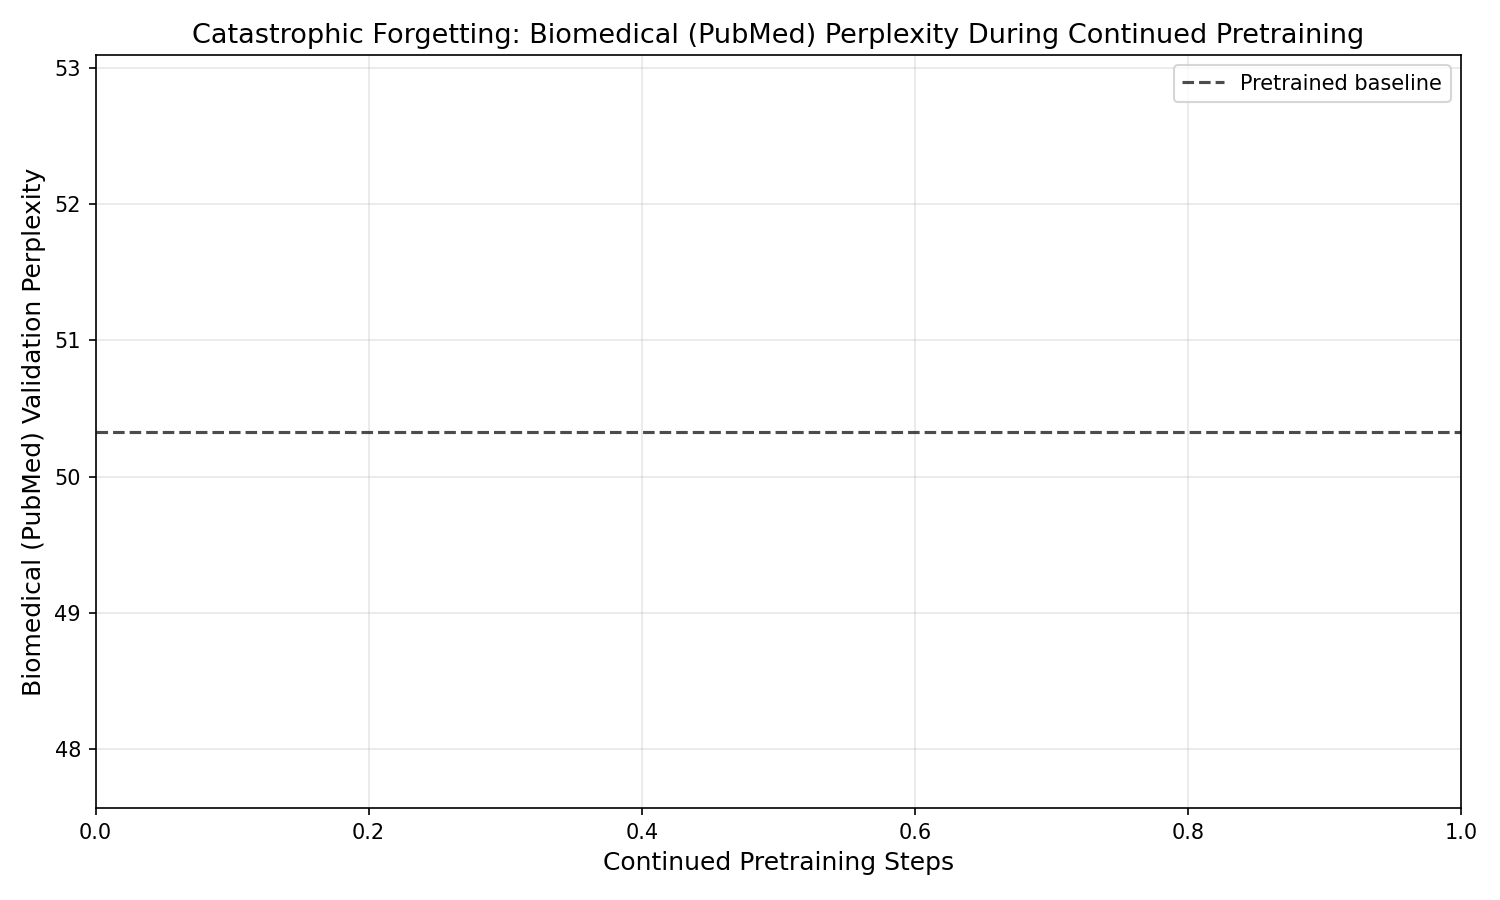

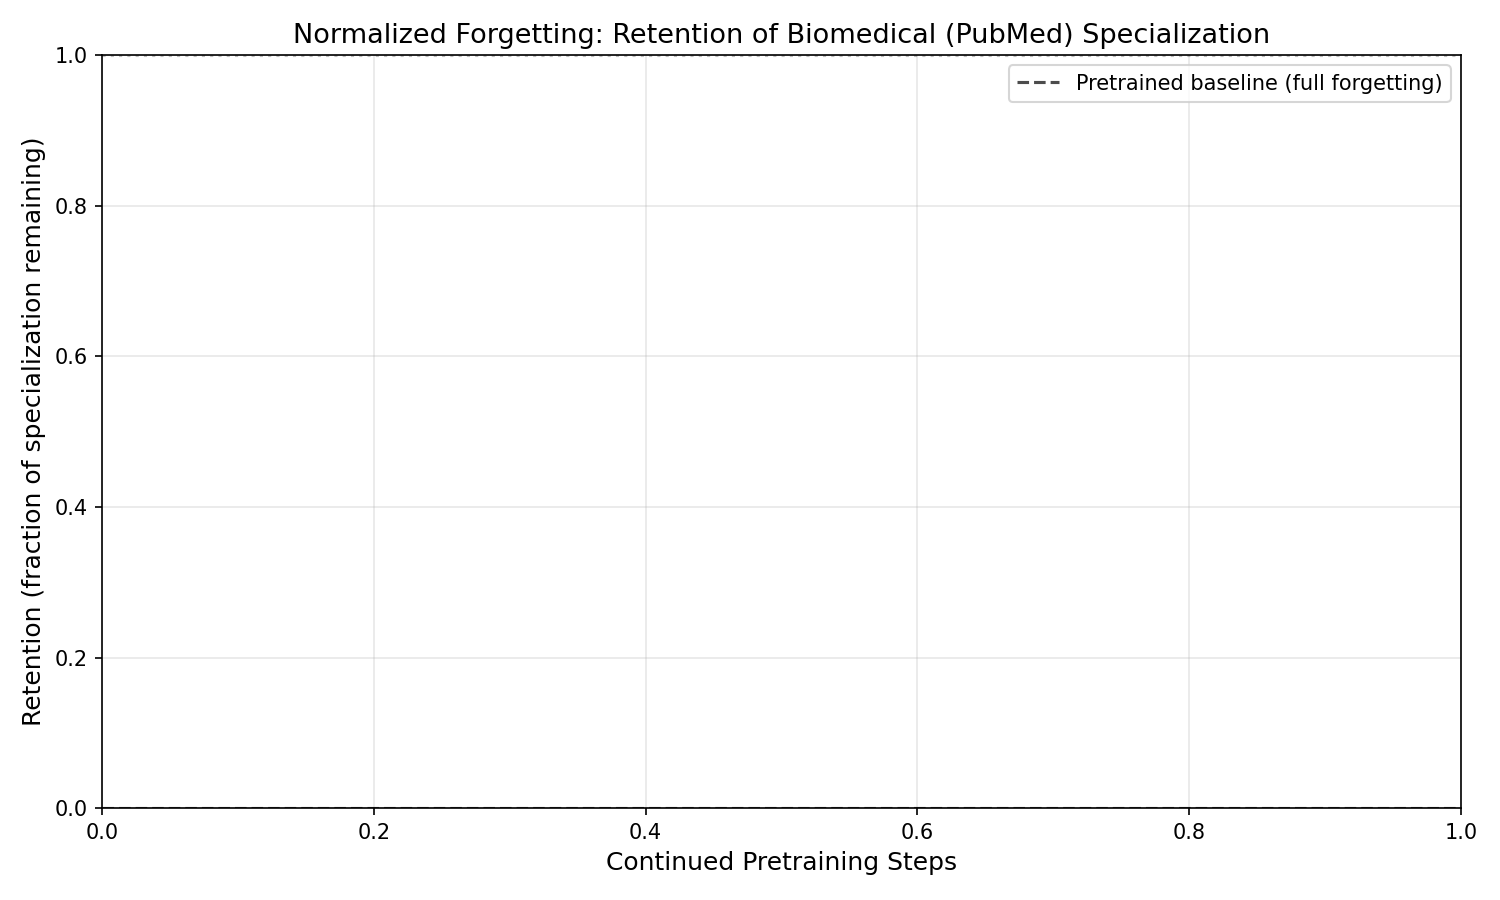

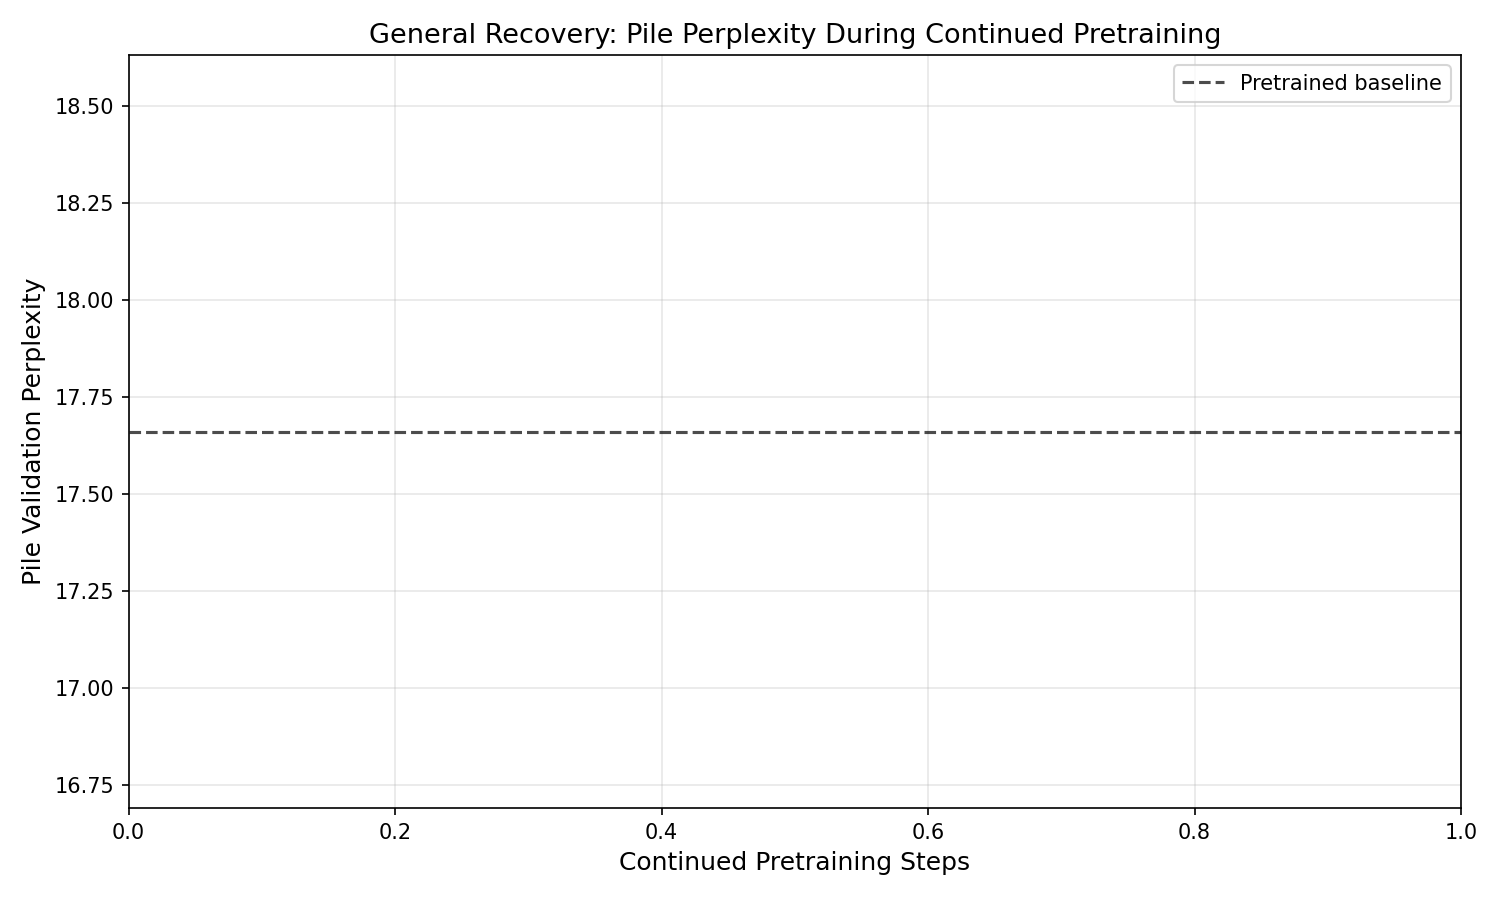

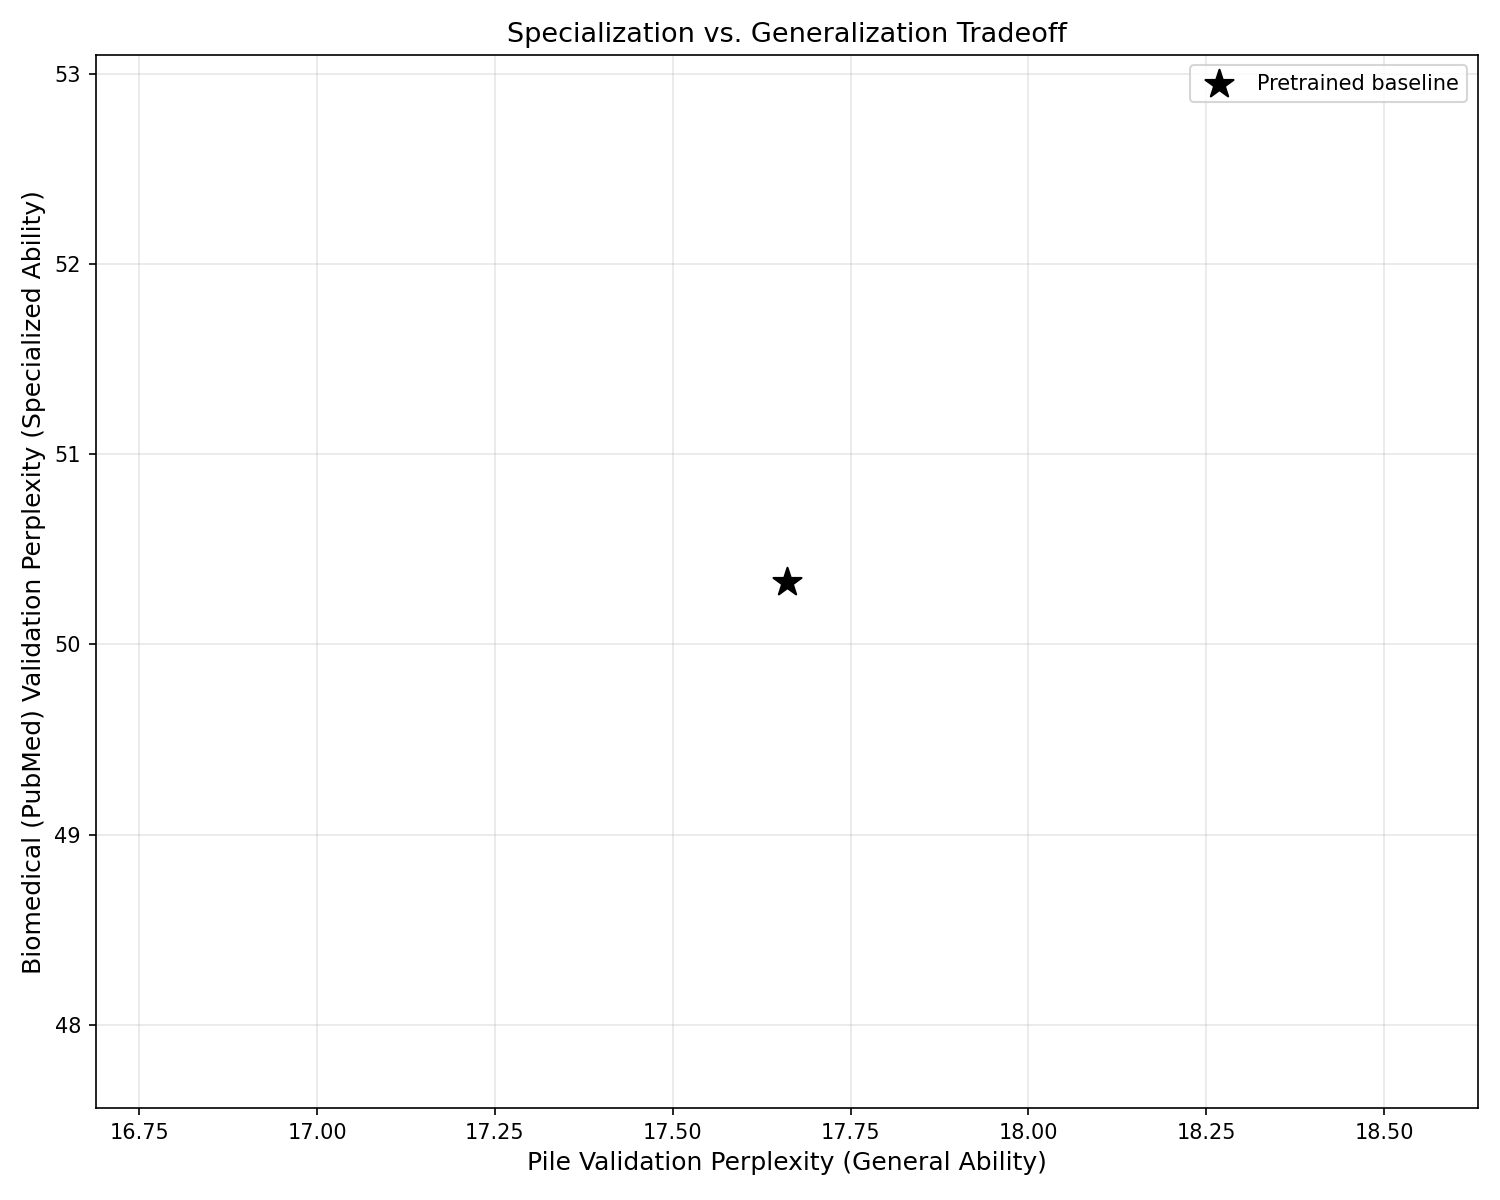

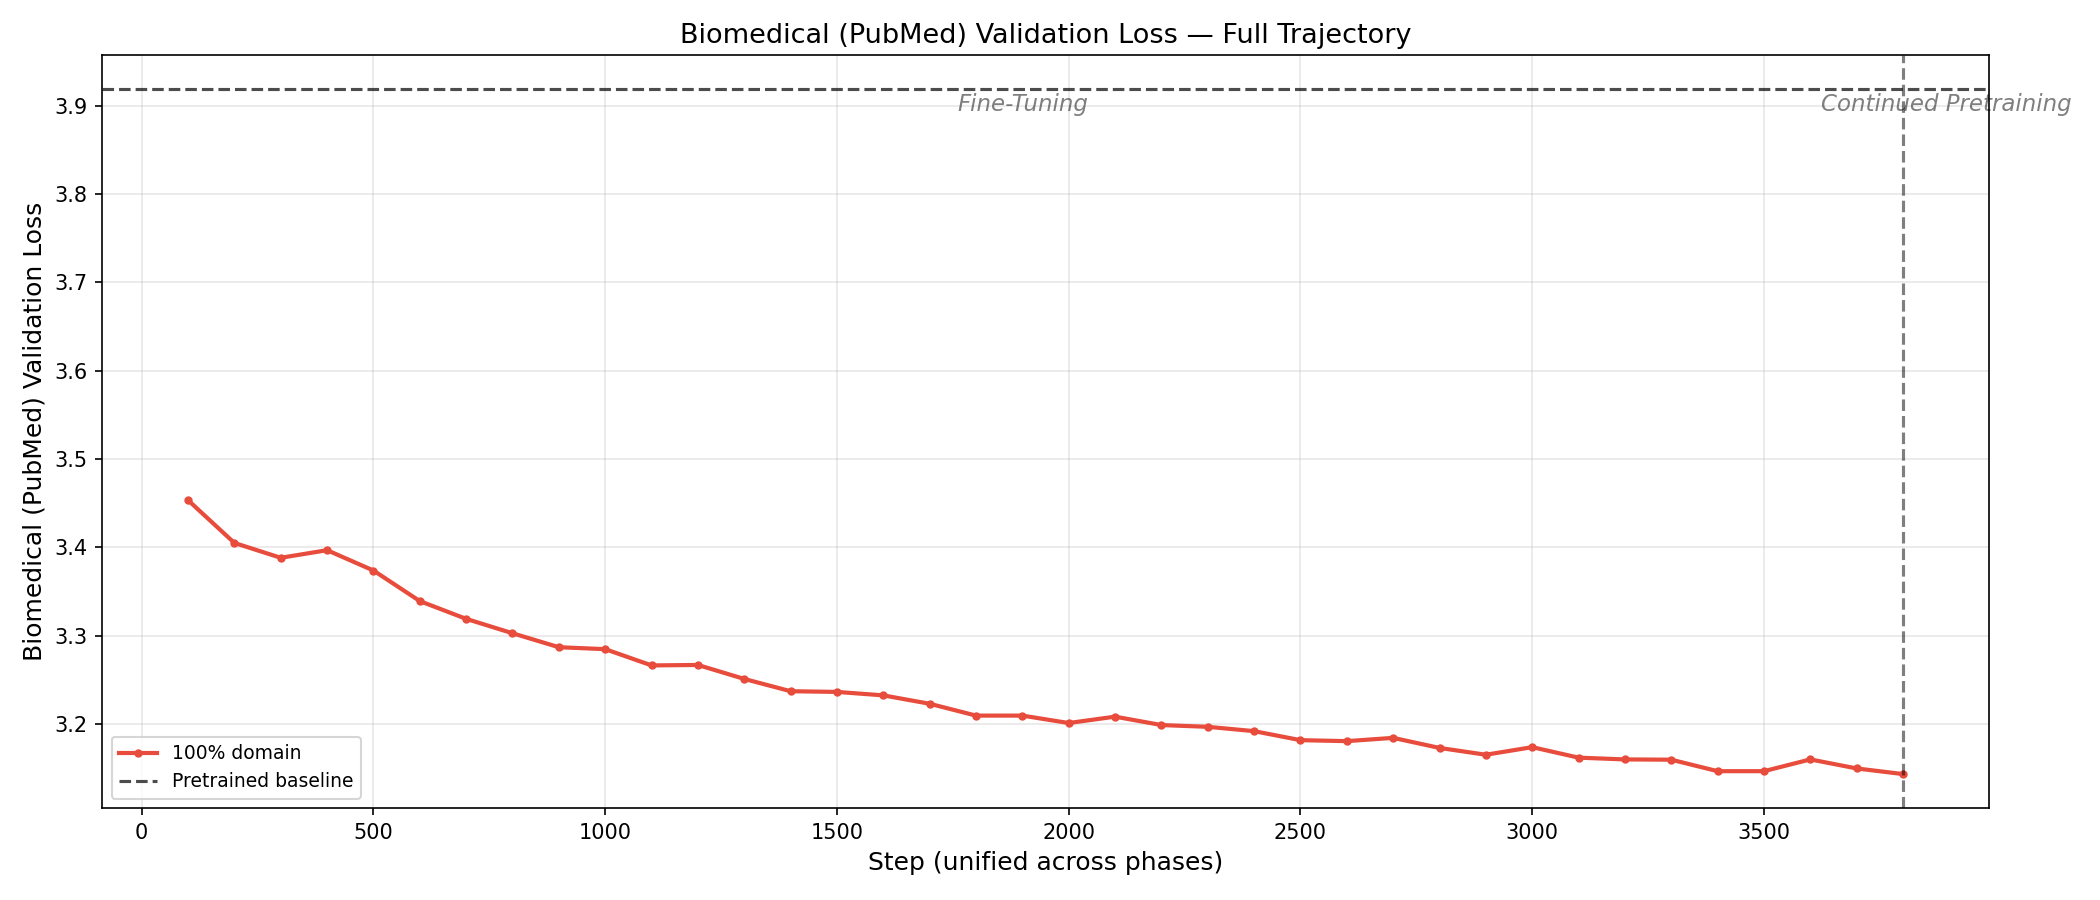

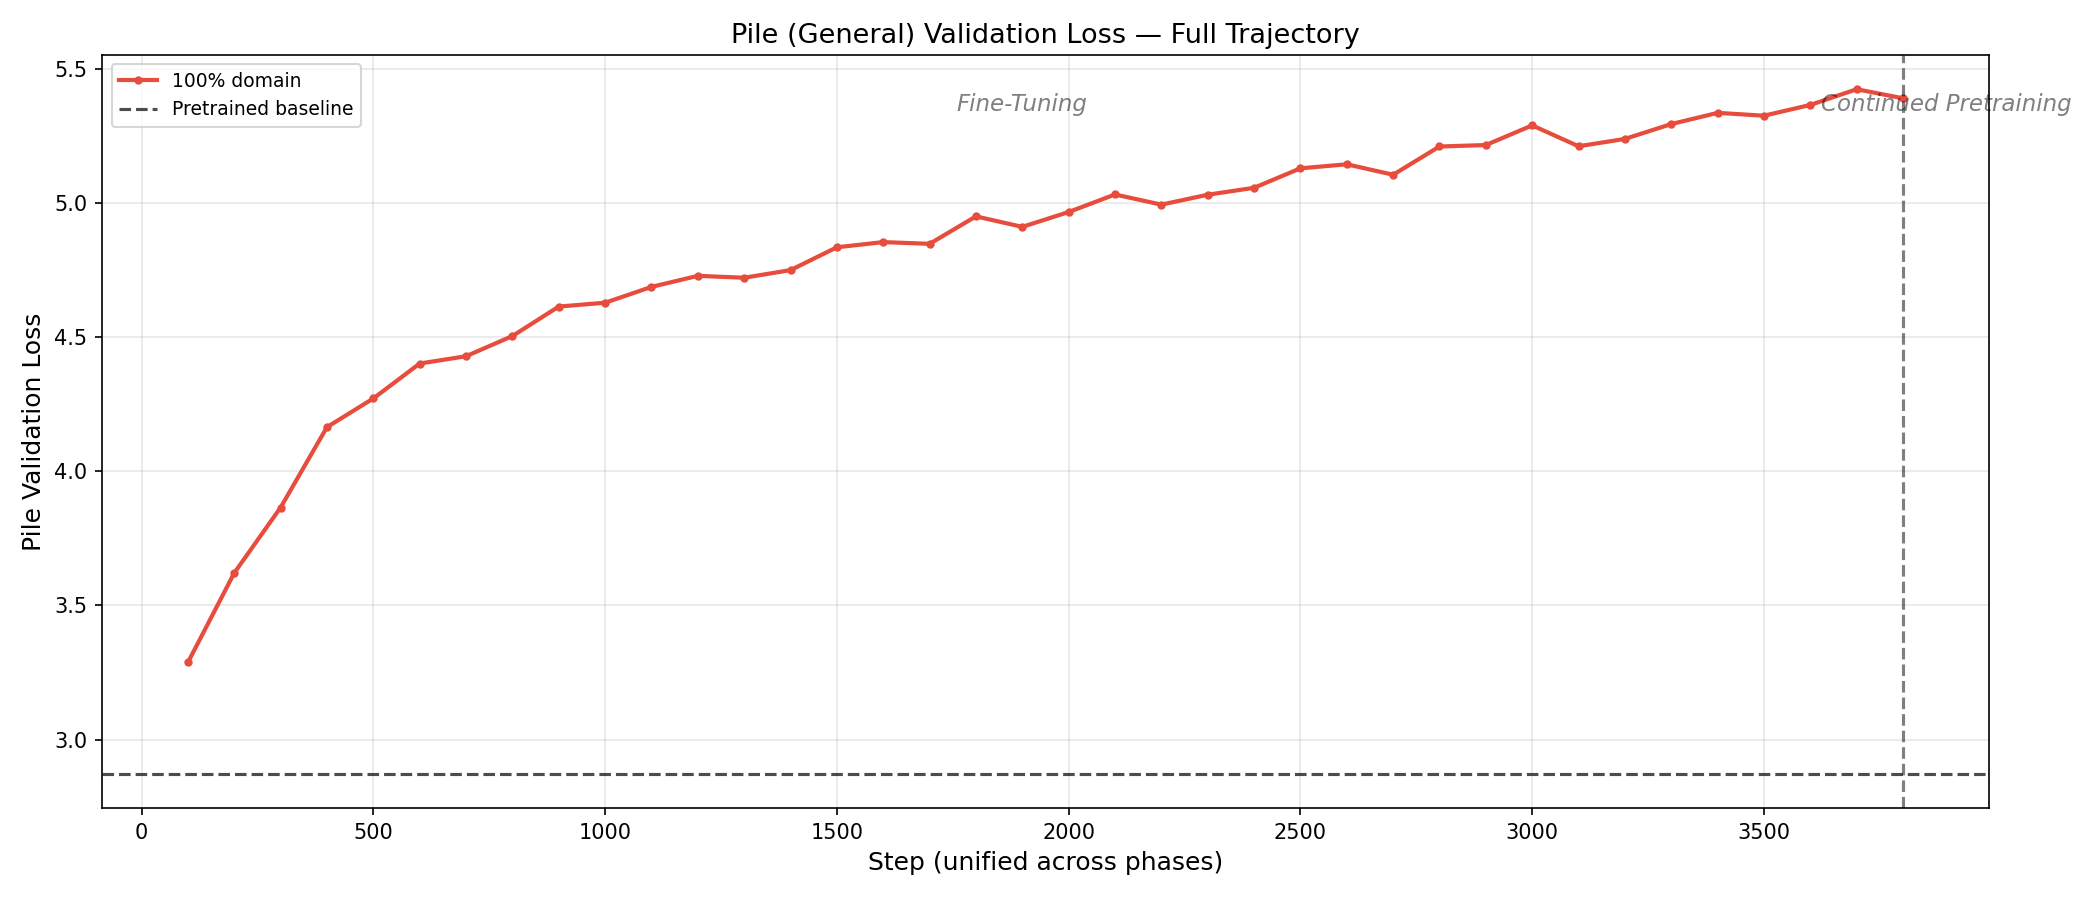

In [7]:
from IPython.display import Image

# Generate and display core plots
plot_forgetting_curves(metrics, RESULTS_DIR)
plot_normalized_forgetting(metrics, RESULTS_DIR)
plot_general_recovery(metrics, RESULTS_DIR)
plot_2d_tradeoff(metrics, RESULTS_DIR)
plot_finetune_comparison(metrics, RESULTS_DIR)
plot_domain_val_loss(metrics, RESULTS_DIR)
plot_pile_val_loss(metrics, RESULTS_DIR)
if loss_history:
    plot_training_loss(loss_history, RESULTS_DIR)

for fname in [
    "plot_forgetting_curves.png",
    "plot_normalized_forgetting.png",
    "plot_general_recovery.png",
    "plot_2d_tradeoff.png",
    "plot_finetune_comparison.png",
    "plot_domain_val_loss.png",
    "plot_pile_val_loss.png",
    "plot_training_loss.png",
]:
    path = os.path.join(RESULTS_DIR, fname)
    if os.path.exists(path):
        display(Image(filename=path))

## Gradient analysis plots
Requires the experiment to have been run with `--grads`.

Saved: results/20260412_144645_deep_biomedical/plot_grad_cosine_sim.png
Saved: results/20260412_144645_deep_biomedical/plot_domain_grad_norm.png


Saved: results/20260412_144645_deep_biomedical/plot_pile_grad_norm.png
Saved: results/20260412_144645_deep_biomedical/plot_pile_grad_norm_cosine.png


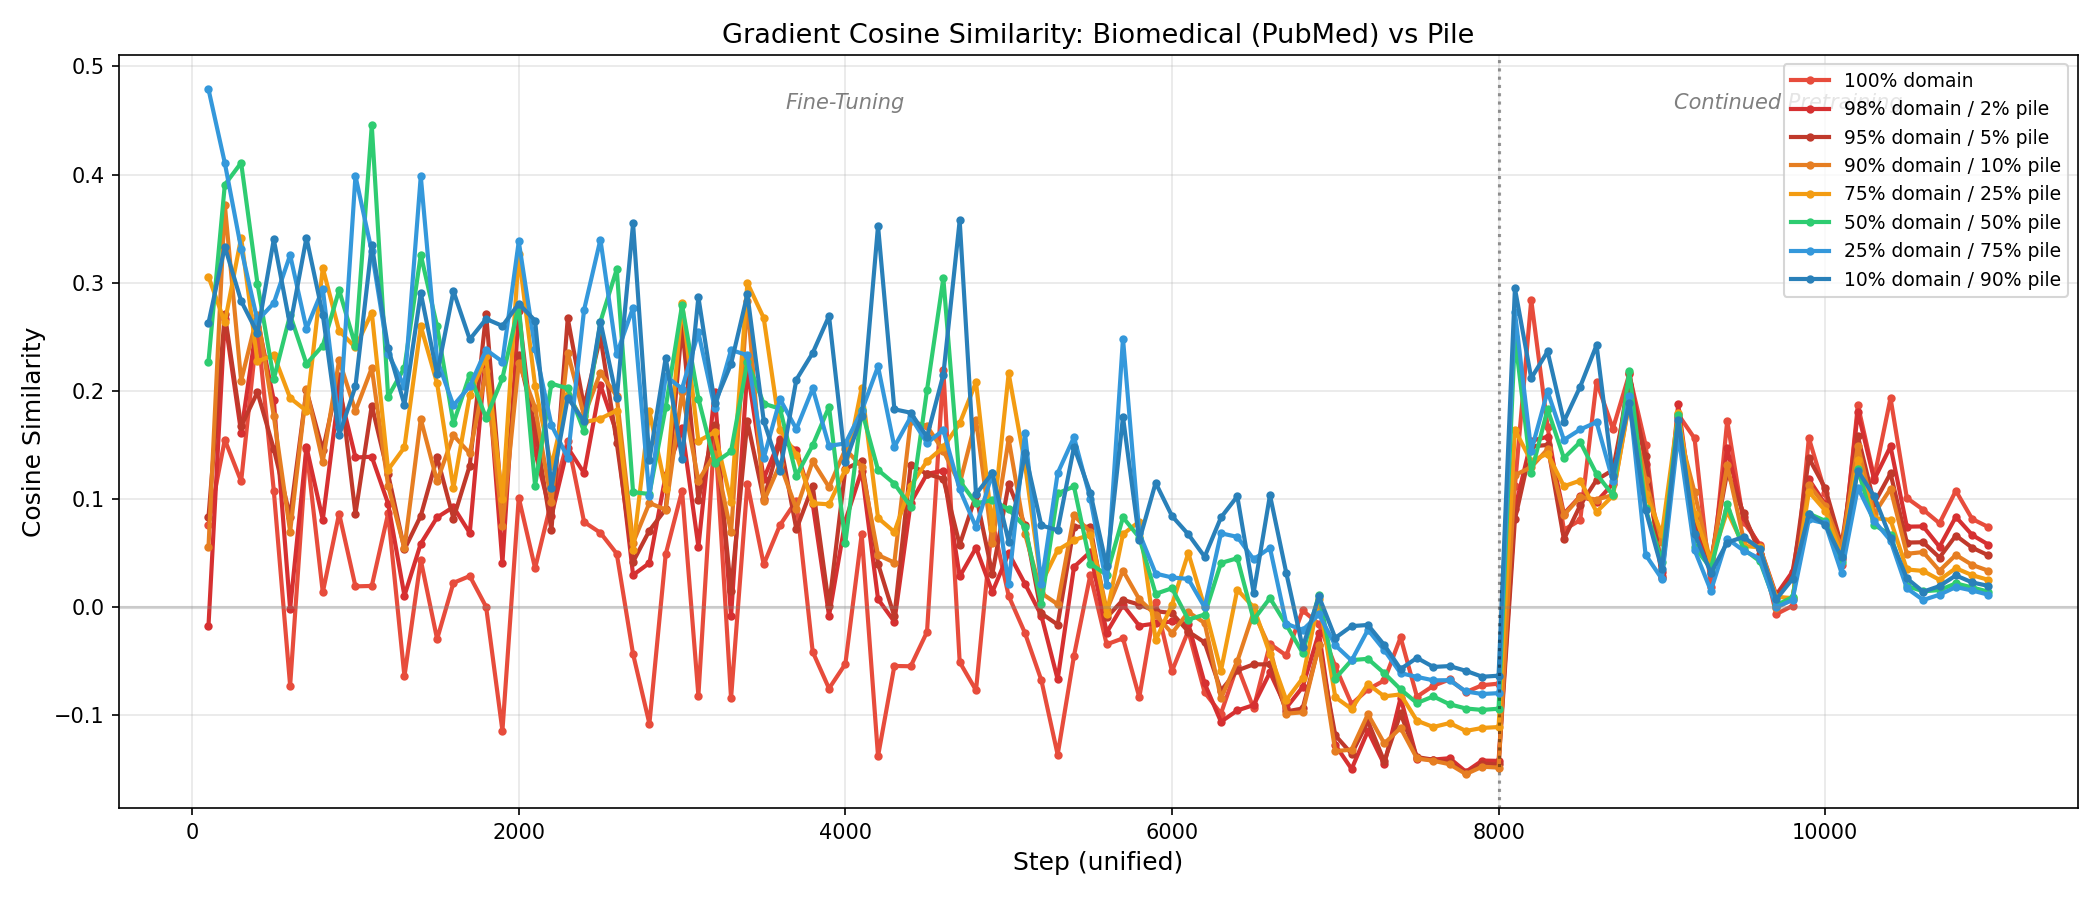

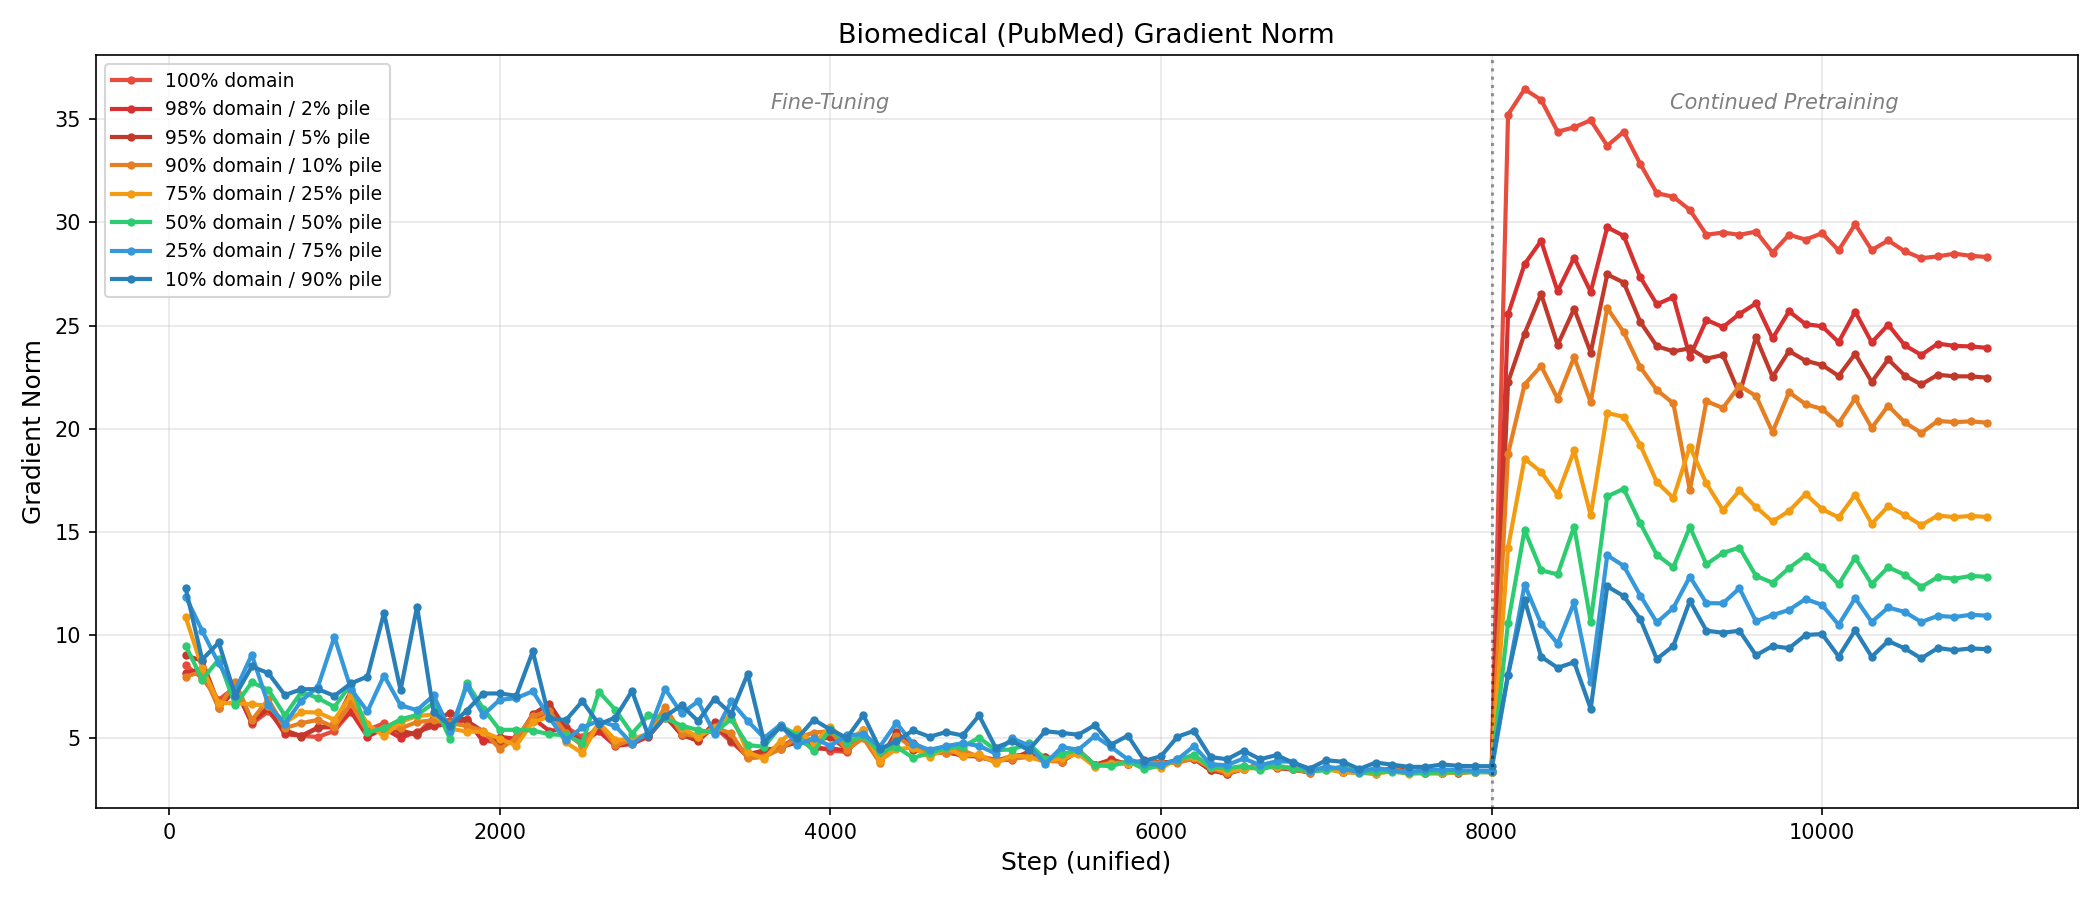

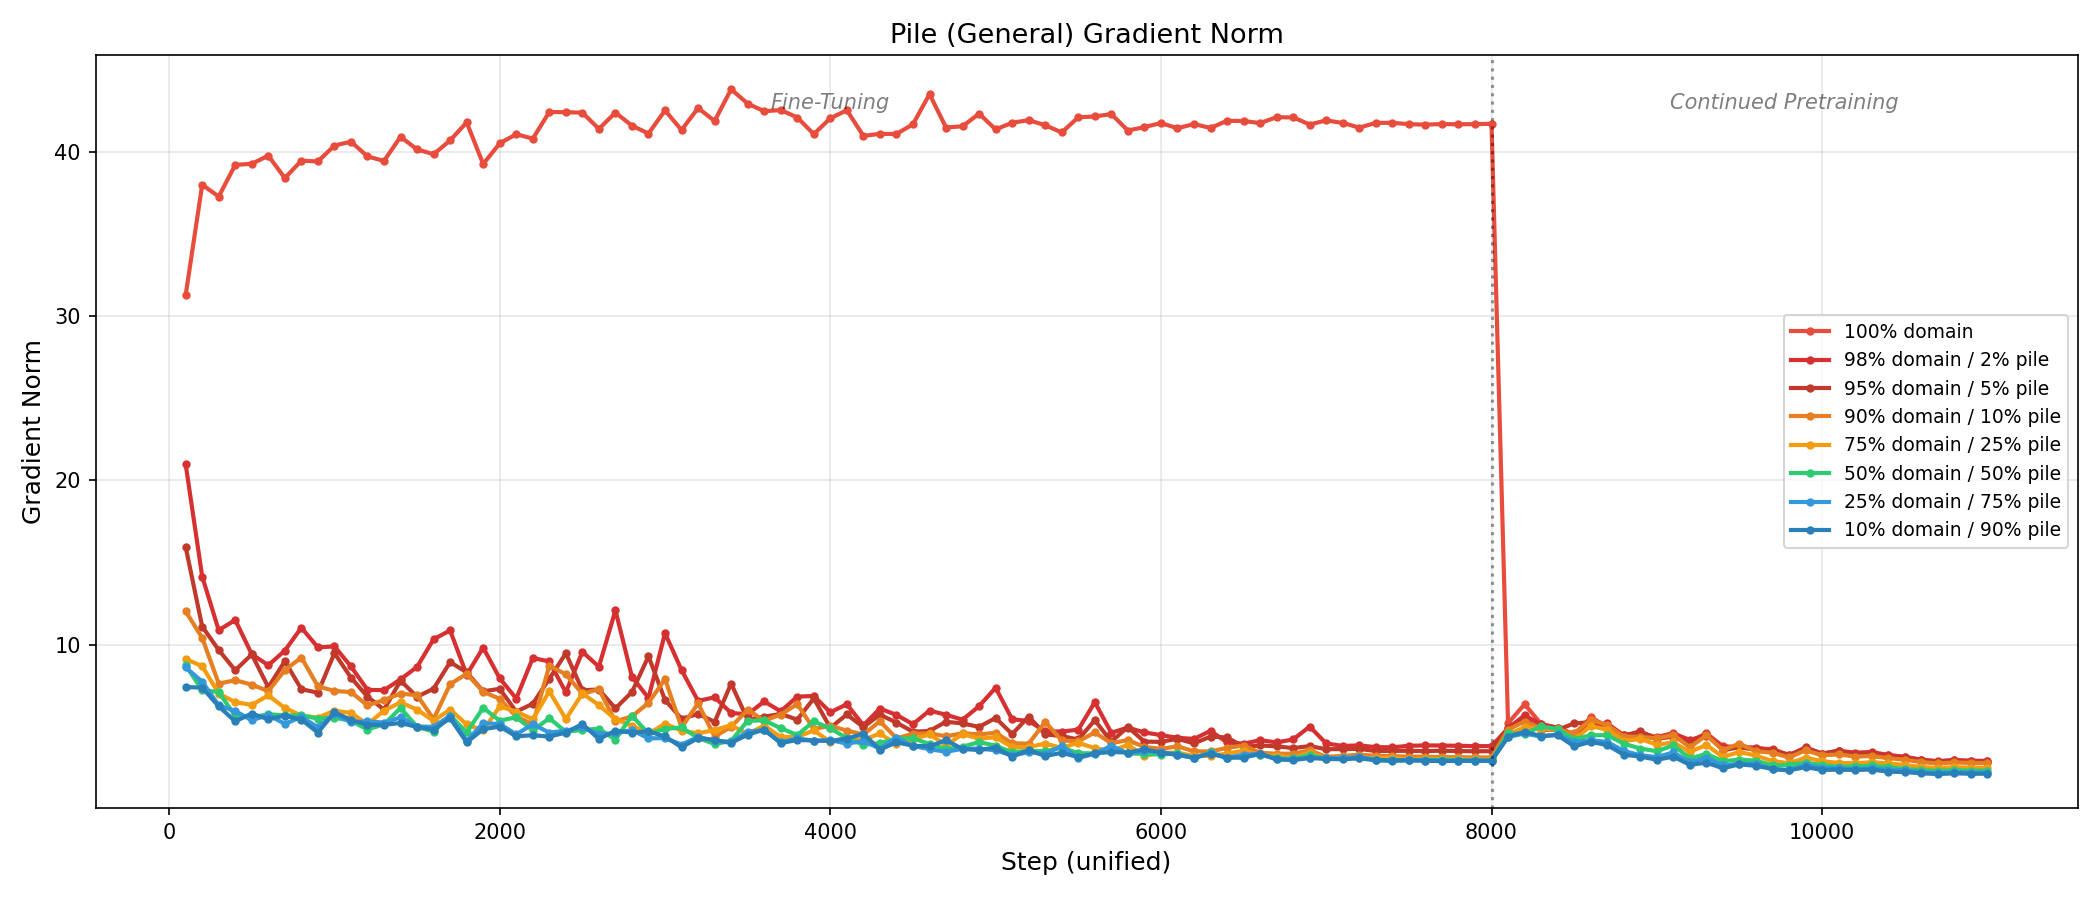

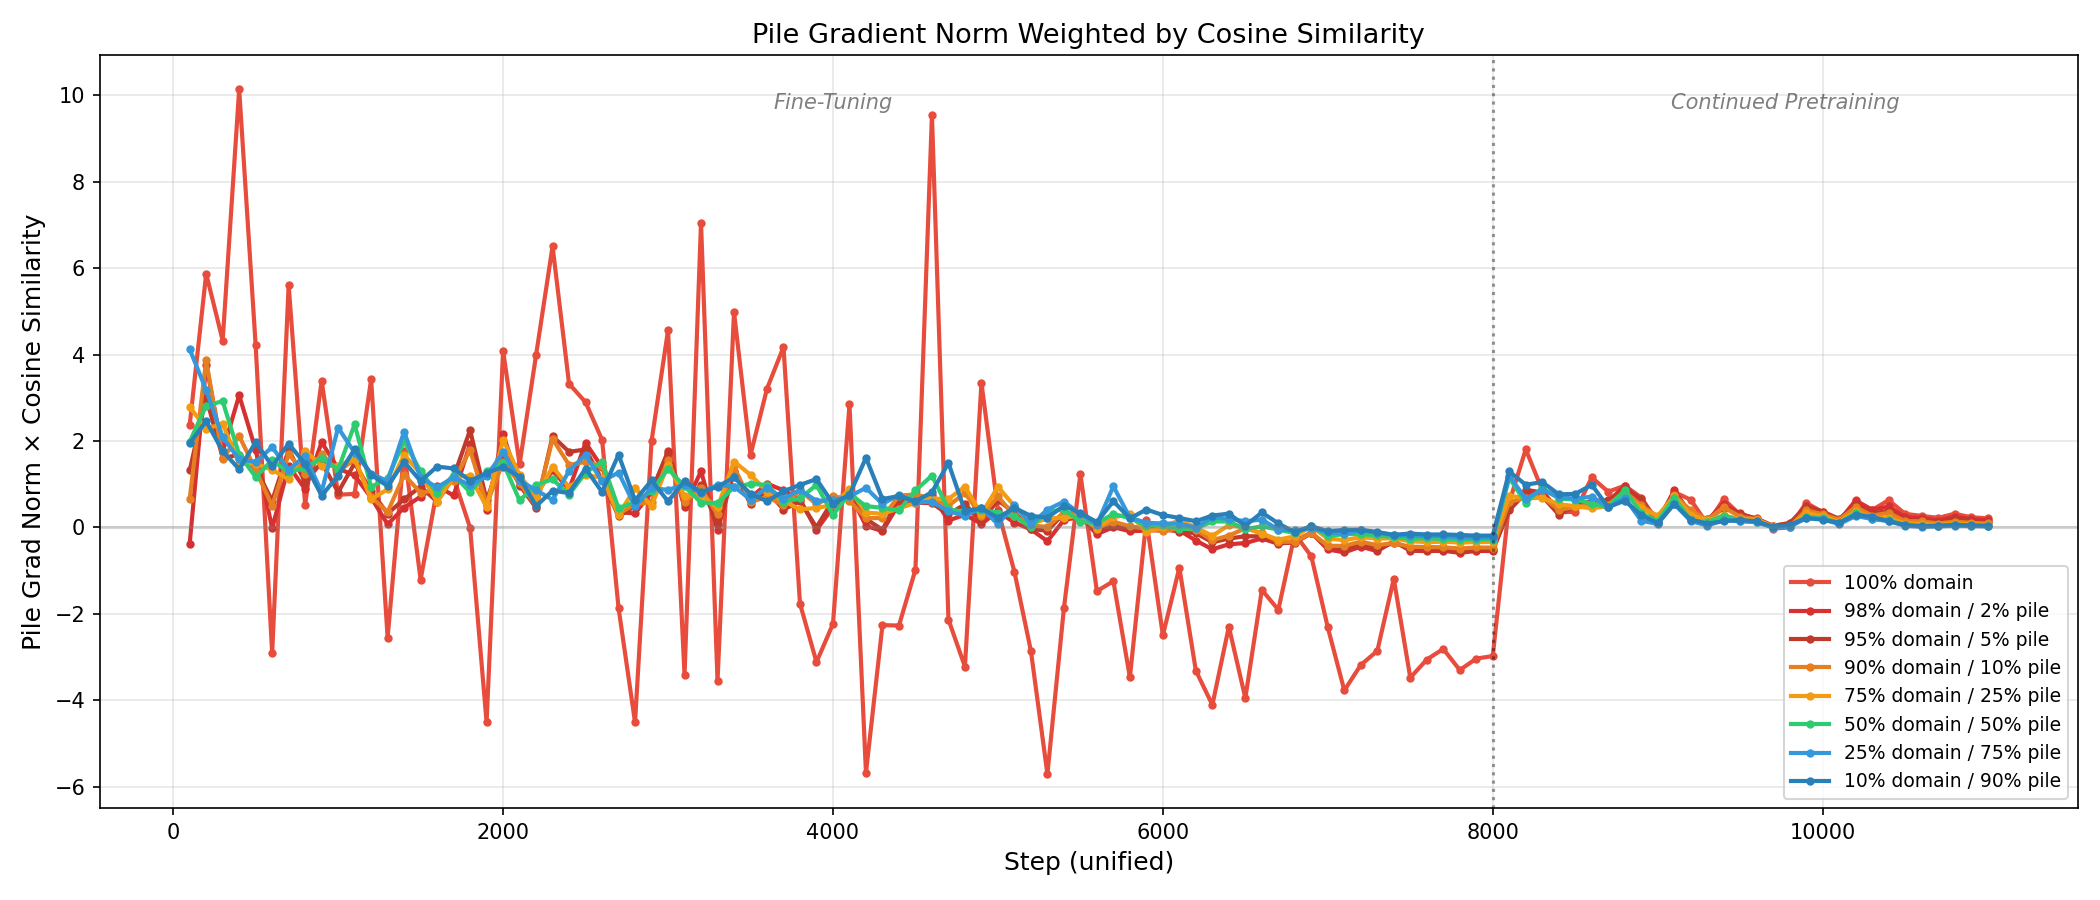

In [ ]:
if grad_metrics:
    plot_grad_cosine_sim(grad_metrics, RESULTS_DIR)
    plot_domain_grad_norm(grad_metrics, RESULTS_DIR)
    plot_pile_grad_norm(grad_metrics, RESULTS_DIR)
    plot_pile_grad_norm_cosine(grad_metrics, RESULTS_DIR)

    for fname in [
        "plot_grad_cosine_sim.png",
        "plot_domain_grad_norm.png",
        "plot_pile_grad_norm.png",
        "plot_pile_grad_norm_cosine.png",
    ]:
        path = os.path.join(RESULTS_DIR, fname)
        if os.path.exists(path):
            display(Image(filename=path))
else:
    pass

## Summary tables

In [ ]:
import pandas as pd

df = pd.DataFrame(metrics)

# Post-fine-tuning snapshot
ft_df = df[df["phase"] == "post_finetune"].sort_values("burst_level", ascending=False)
display(ft_df[["burst_level", "domain_val_perplexity", "pile_val_perplexity"]])

# Final continued-pretraining snapshot
cpt_df = df[df["phase"] == "continued_pretraining"]
if len(cpt_df):
    final = cpt_df.loc[cpt_df.groupby("burst_level")["step"].idxmax()].sort_values("burst_level", ascending=False)
    display(final[["burst_level", "step", "domain_val_perplexity", "pile_val_perplexity"]])

Post-Fine-Tuning Metrics:


,burst_level,domain_val_perplexity,pile_val_perplexity
81,1.00,20.36,114.60
192,0.98,20.44,16.93
303,0.95,20.52,15.71
414,0.90,20.63,15.02
525,0.75,21.00,14.33
636,0.50,21.77,13.89
747,0.25,23.06,13.66
858,0.10,24.89,13.56



Final Continued Pretraining Metrics:


,burst_level,step,domain_val_perplexity,pile_val_perplexity
111,1.00,3000,35.56,13.87
222,0.98,3000,31.43,13.86
333,0.95,3000,30.28,13.86
444,0.90,3000,28.99,13.85
555,0.75,3000,27.67,13.83
666,0.50,3000,27.20,13.79
777,0.25,3000,27.94,13.75
888,0.10,3000,29.32,13.74


In [ ]:
# ── Dataset samples ──
from datasets import load_dataset

ds = load_dataset("antoinebcx/smiles-molecules-chembl", split="train", streaming=True)
for i, ex in enumerate(ds):
    if i >= 5: break

ds = load_dataset("sander-wood/irishman", split="train", streaming=True)
for i, ex in enumerate(ds):
    if i >= 3: break
    abc = ex["abc notation"][:200].replace("\n", " | ")

ds = load_dataset("ccdv/pubmed-summarization", split="train", streaming=True)
for i, ex in enumerate(ds):
    if i >= 3: break
    text = ex["article"][:300].replace("\n", " ")

ds = load_dataset("monology/pile-uncopyrighted", split="train", streaming=True)
for i, ex in enumerate(ds):
    if i >= 3: break
    text = ex["text"][:300].replace("\n", " ")


=== Domain: Chemistry — SMILES Molecules (ChEMBL) ===
Each sample is a SMILES string representing a molecular structure.



Repo card metadata block was not found. Setting CardData to empty.


  [0] O=C(c1cc(-c2cc3c(cc2C(=O)N2Cc4ccccc4C[C@H]2CN2CCOCC2)OCO3)n2c1CCCC2)N(c1ccc(O)cc1)c1ccc(Cl)cc1
  [1] CC(=O)N1CCC(C(=O)N2CC[C@](c3ccc(C(OCc4ccccc4C#N)(C(F)(F)F)C(F)(F)F)cc3)(S(=O)(=O)c3ccc(F)cc3)C2)CC1
  [2] CC(C)Nc1c(C(N)=O)nnc2ccc(-c3cnn(C)c3)cc12
  [3] CC(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H](CCC(N)=O)C(=O)N[C@@H](CO)C(=O)N[C@@H](CCCCN)C(=O)NCC(=O)N[C@@H](CC(N)=O)C(=O)N[C@H](C(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@H](C(=O)N[C@@H](Cc1ccccc1)C(=O)NCC(=O)N[C@H](CC(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H](CCC(=O)O)C(=O)N[C@@H](CCCNC(=N)N)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](CCCNC(=N)N)C(=O)N[C@@H](C)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CC(C)C)C(N)=O)Cc1ccc(O)cc1)C(C)C)C(C)C
  [4] CNC(=O)c1ccc(NC(=O)Nc2ccc(-c3nc(N4CCOCC4)c4ncccc4n3)cc2)cc1

=== Domain: Music — Irish ABC Notation (irishman) ===
Each sample is a tune in ABC notation.

  [0] X:1 | L:1/8 | M:4/4 | K:Emin | |: E2 EF E2 EF | DEFG AFDF | E2 EF E2 B2 |1 efe^d e2 e2 :|2 efe^d e3 B |: e2 ef g2 fe |  |  defg afdf |1 e2 ef g2 fe | efe^d e3 B :|2 g2 bg f2 

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

  [0] It is done, and submitted. You can play “Survival of the Tastiest” on Android, and on the web. Playing on the web works, but you have to simulate multi-touch for table moving and that can be a bit confusing.  There’s a lot I’d like to talk about. I’ll go through every topic, insted of making the typ...

             <...cription>Living Dependency</description>tion>

  [2] Topic: reinvent midnight madness  Amazon announced a new service at the AWS re:Invent Midnight Madness event. Amazon Sumerian is a solution that aims to make it easier for developers to build virtual reality, augmented reality, and 3D applications. It features a user friendly editor, which can be us...



---
## Curvature Coupling Analysis

Study second-order effects: does task A's loss increase during training on task B even when gradients are orthogonal?
This implies the loss surface of A is curved in the gradient direction of B.

**Requires**: saved model checkpoints in `RESULTS_DIR/models/burst_X_XX/post_finetune/`

In [ ]:

import numpy as np
import torch
import torch.nn.functional as F
from config import ExperimentConfig
from data import (
    make_eval_loader,
    make_pile_loader,
    prepare_datasets,
)
from tqdm import tqdm
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
)

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load config from the selected results dir
cfg = ExperimentConfig.from_json(os.path.join(RESULTS_DIR, "config.json"))

# Load tokenizer + prepare datasets (cached, should be instant)
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
datasets = prepare_datasets(cfg, tokenizer)


Preparing datasets...

[1/4] Domain training data
  → Domain train: loaded from cache (321000 chunks of 512 tokens)

[2/4] Domain validation data (split='validation')
  → Domain valid: loaded from cache (2000 chunks of 512 tokens)

[3/4] Pile training + validation data (single stream, no overlap)
  → Pile all: loaded from cache (444000 chunks of 512 tokens)
  → Pile train: 442000 chunks, Pile valid: 2000 chunks
Device: cuda
Datasets ready: domain_train=321000, pile_train=442000, domain_valid=2000, pile_valid=2000


In [ ]:
# ── Utility functions for curvature analysis ──

def get_grad_vector(model, dataset, batch_size=16, num_batches=10):
    """Compute gradient of loss on a dataset, return as flat vector."""
    model.eval()
    model.zero_grad()
    loader = make_eval_loader(dataset, batch_size)
    count = 0
    for i, batch in enumerate(loader):
        if i >= num_batches:
            break
        input_ids = batch.to(device)
        outputs = model(input_ids=input_ids, labels=input_ids)
        outputs.loss.backward()
        count += 1
    for p in model.parameters():
        if p.grad is not None:
            p.grad /= max(count, 1)
    grads = [p.grad.detach().flatten() for p in model.parameters() if p.grad is not None]
    model.zero_grad()
    return torch.cat(grads)


def eval_loss(model, dataset, batch_size=16, num_batches=10):
    """Compute average loss on a dataset."""
    model.eval()
    loader = make_eval_loader(dataset, batch_size)
    total, count = 0.0, 0
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if i >= num_batches:
                break
            input_ids = batch.to(device)
            total += model(input_ids=input_ids, labels=input_ids).loss.item()
            count += 1
    return total / max(count, 1)


def get_flat_params(model):
    """Get all model parameters as a single flat vector."""
    return torch.cat([p.detach().flatten() for p in model.parameters()])


def set_flat_params(model, flat) -> None:
    """Set model parameters from a flat vector."""
    offset = 0
    for p in model.parameters():
        numel = p.numel()
        p.data.copy_(flat[offset:offset+numel].view_as(p))
        offset += numel


def compute_kappa(model, direction, task_dataset, epsilon=1e-3, batch_size=16, num_batches=10):
    """Compute curvature coupling: kappa = v^T H_A v via finite-difference HVP.

    H*v ≈ (grad_L(θ+εv) - grad_L(θ-εv)) / 2ε, then κ = v^T · (H*v).
    direction should be a unit vector.
    """
    theta = get_flat_params(model)

    # θ + εv
    set_flat_params(model, theta + epsilon * direction)
    grad_plus = get_grad_vector(model, task_dataset, batch_size, num_batches)

    # θ - εv
    set_flat_params(model, theta - epsilon * direction)
    grad_minus = get_grad_vector(model, task_dataset, batch_size, num_batches)

    # Restore
    set_flat_params(model, theta)

    hvp = (grad_plus - grad_minus) / (2 * epsilon)
    return torch.dot(direction, hvp).item()


def directional_derivative(model, direction, task_dataset, alphas, batch_size=16, num_batches=10):
    """Evaluate loss along θ + α * direction for each α. Returns list of losses."""
    theta = get_flat_params(model)
    losses = []
    for a in alphas:
        set_flat_params(model, theta + a * direction)
        losses.append(eval_loss(model, task_dataset, batch_size, num_batches))
    set_flat_params(model, theta)
    return losses



Curvature utilities loaded.


In [ ]:
# ── Pick burst levels and load checkpoints ──
BURSTS = [1.0, 0.9,0.5, 0.1]  # change this list to study different burst levels

# Load all checkpoints and compute initial gradients
burst_data = {}  # bl -> {model, theta_0, grad_domain, grad_pile, g_domain_hat, g_pile_hat, cossim_0, ckpt_dir}
for bl in BURSTS:
    burst_tag = f"burst_{bl:.2f}".replace(".", "_")
    cd = os.path.abspath(os.path.join(RESULTS_DIR, "models", burst_tag, "post_finetune"))
    assert os.path.exists(cd), f"Checkpoint not found: {cd}"

    m = AutoModelForCausalLM.from_pretrained(cd, torch_dtype=torch.float32).to(device)
    t0 = get_flat_params(m)
    gd = get_grad_vector(m, datasets["domain_valid"])
    gp = get_grad_vector(m, datasets["pile_valid"])
    cs = F.cosine_similarity(gd.unsqueeze(0), gp.unsqueeze(0)).item()

    burst_data[bl] = {
        "ckpt_dir": cd, "theta_0": t0,
        "grad_domain": gd, "grad_pile": gp,
        "g_domain_hat": gd / gd.norm(), "g_pile_hat": gp / gp.norm(),
        "cossim_0": cs,
    }
    del m; torch.cuda.empty_cache()




`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

burst=100%  cossim=-0.071312  ||g_d||=3.3644  ||g_p||=41.7131


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

burst=90%  cossim=-0.149046  ||g_d||=3.3524  ||g_p||=3.1274


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

burst=50%  cossim=-0.094514  ||g_d||=3.3442  ||g_p||=2.9513


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

burst=10%  cossim=-0.063955  ||g_d||=3.6362  ||g_p||=2.9220

Loaded 4 checkpoints.


### Kappa at θ_0 — initial curvature coupling
`κ_domain = ĝ_pile^T · H_domain · ĝ_pile` — curvature of domain loss surface along pile gradient direction.
`κ_pile = ĝ_domain^T · H_pile · ĝ_domain` — curvature of pile loss surface along domain gradient direction.

In [ ]:
# κ at θ_0 for all burst levels
kappa_summary = []
for bl in BURSTS:
    bd = burst_data[bl]
    m = AutoModelForCausalLM.from_pretrained(bd["ckpt_dir"], torch_dtype=torch.float32).to(device)
    k_d = compute_kappa(m, bd["g_pile_hat"], datasets["domain_valid"])
    k_p = compute_kappa(m, bd["g_domain_hat"], datasets["pile_valid"])
    del m; torch.cuda.empty_cache()
    kappa_summary.append({"burst": bl, "cossim": bd["cossim_0"], "kappa_domain": k_d, "kappa_pile": k_p})

display(pd.DataFrame(kappa_summary))


=== κ at θ_0 (post-FT checkpoint) ===
For each burst level, we measure at the post-finetune checkpoint:
  - cossim: cosine similarity between domain and pile gradients (first-order conflict signal)
  - κ_domain: curvature of domain loss surface along pile gradient direction
    → positive = stepping along pile gradient increases domain loss even if gradients are orthogonal
  - κ_pile: curvature of pile loss surface along domain gradient direction
    → positive = domain training would damage pile via the same second-order mechanism
If cossim ≈ 0 but κ_domain >> 0, forgetting is a curvature effect, not a gradient conflict.



Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

burst=100%  cossim=-0.071312  κ_domain=824.439575  κ_pile=1036.451050


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

burst=90%  cossim=-0.149046  κ_domain=374.170410  κ_pile=667.934021


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

burst=50%  cossim=-0.094514  κ_domain=334.756470  κ_pile=554.486389


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

burst=10%  cossim=-0.063955  κ_domain=436.454926  κ_pile=515.472290


,burst,cossim,kappa_domain,kappa_pile
0,1.0,-0.071312,824.439575,1036.451050
1,0.9,-0.149046,374.170410,667.934021
2,0.5,-0.094514,334.756470,554.486389
3,0.1,-0.063955,436.454926,515.472290


### 1D Wiggle Test
From θ_0, step along ĝ_pile and measure domain loss. If it rises quadratically with cossim ≈ 0, that's curvature coupling.

=== 1D Wiggle Test ===
From each post-FT checkpoint θ_0, we move along the unit pile gradient: θ = θ_0 + α·ĝ_pile
and measure at each α:
  Left:   Domain loss — if it rises quadratically with α despite cossim ≈ 0, that's curvature coupling
  Middle: Pile loss — should decrease (we're stepping along its own gradient)
  Right:  cos(g_domain, g_pile) — gradient alignment at each probed point
    → if cossim shifts from 0 after a small step, curvature is rotating gradients into conflict
α = 0 is the checkpoint. α > 0 = moving in pile's descent direction.



Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

wiggle burst=100%:   0%|          | 0/21 [00:00<?, ?it/s]

wiggle burst=100%: 100%|██████████| 21/21 [00:40<00:00,  1.91s/it]


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

wiggle burst=90%: 100%|██████████| 21/21 [00:40<00:00,  1.92s/it]


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

wiggle burst=50%: 100%|██████████| 21/21 [00:40<00:00,  1.92s/it]


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

wiggle burst=10%: 100%|██████████| 21/21 [00:40<00:00,  1.92s/it]


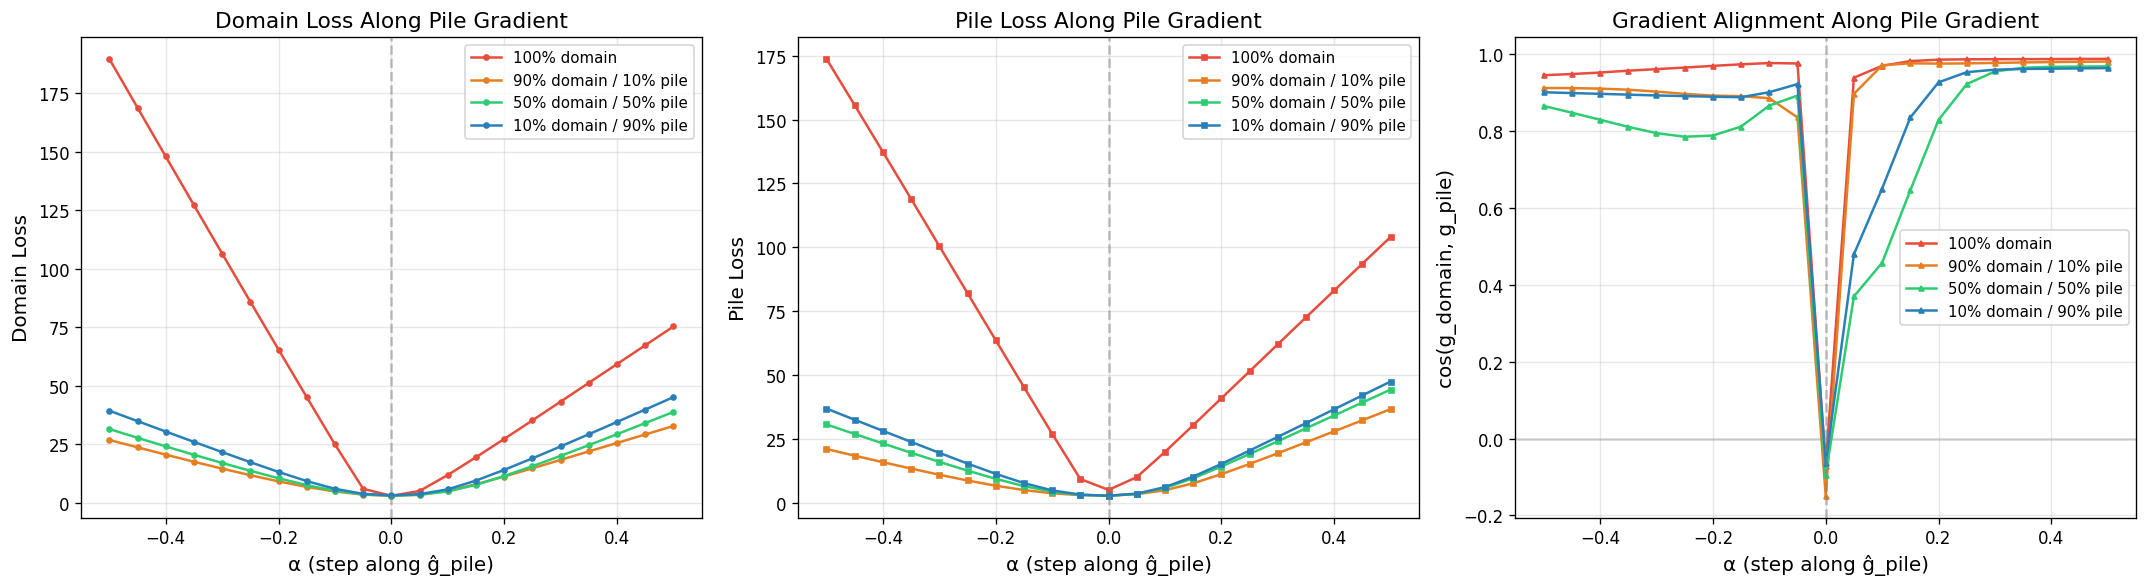

In [ ]:
# 1D wiggle test — all burst levels overlaid
alphas = np.linspace(-0.5, 0.5, 21)

# Collect losses and cossim at each alpha for each burst
wiggle_data = {}  # bl -> {"domain": [...], "pile": [...], "cossim": [...]}

for bl in BURSTS:
    bd = burst_data[bl]
    m = AutoModelForCausalLM.from_pretrained(bd["ckpt_dir"], torch_dtype=torch.float32).to(device)
    theta = get_flat_params(m)
    d_wig, p_wig, cs_wig = [], [], []
    for a in tqdm(alphas, desc=f"wiggle burst={bl:.0%}"):
        set_flat_params(m, theta + a * bd["g_pile_hat"])
        d_wig.append(eval_loss(m, datasets["domain_valid"]))
        p_wig.append(eval_loss(m, datasets["pile_valid"]))
        gd = get_grad_vector(m, datasets["domain_valid"])
        gp = get_grad_vector(m, datasets["pile_valid"])
        cs_wig.append(F.cosine_similarity(gd.unsqueeze(0), gp.unsqueeze(0)).item())
    set_flat_params(m, theta)
    del m; torch.cuda.empty_cache()
    wiggle_data[bl] = {"domain": d_wig, "pile": p_wig, "cossim": cs_wig}

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
for bl in BURSTS:
    color = plot_module.BURST_COLORS.get(bl, "gray")
    label = plot_module.BURST_LABELS.get(bl, f"{bl:.0%}")
    wd = wiggle_data[bl]
    ax1.plot(alphas, wd["domain"], "o-", color=color, ms=3, lw=1.5, label=label)
    ax2.plot(alphas, wd["pile"],   "s-", color=color, ms=3, lw=1.5, label=label)
    ax3.plot(alphas, wd["cossim"], "^-", color=color, ms=3, lw=1.5, label=label)

ax1.axvline(0, color="gray", ls="--", alpha=0.5)
ax1.set_xlabel("α (step along ĝ_pile)", fontsize=12)
ax1.set_ylabel("Domain Loss", fontsize=12)
ax1.set_title("Domain Loss Along Pile Gradient", fontsize=13)
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

ax2.axvline(0, color="gray", ls="--", alpha=0.5)
ax2.set_xlabel("α (step along ĝ_pile)", fontsize=12)
ax2.set_ylabel("Pile Loss", fontsize=12)
ax2.set_title("Pile Loss Along Pile Gradient", fontsize=13)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

ax3.axvline(0, color="gray", ls="--", alpha=0.5)
ax3.axhline(0, color="gray", ls="-", alpha=0.3)
ax3.set_xlabel("α (step along ĝ_pile)", fontsize=12)
ax3.set_ylabel("cos(g_domain, g_pile)", fontsize=12)
ax3.set_title("Gradient Alignment Along Pile Gradient", fontsize=13)
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

fig.tight_layout(); display(fig); plt.close(fig)


### κ Tracking During CPT
Run a short CPT from the checkpoint, tracking cossim, κ, and losses at every step for the first N steps.
This reveals the transient window where curvature coupling spikes.

In [ ]:
# ── κ tracking during early CPT steps — all burst levels ──
NUM_TRACK_STEPS = 50   # total steps to run
EVAL_EVERY = 1         # measure every N steps

all_tracking = {}  # bl -> DataFrame

for bl in BURSTS:
    bd = burst_data[bl]
    track_model = AutoModelForCausalLM.from_pretrained(bd["ckpt_dir"], torch_dtype=torch.float32).to(device)
    track_model.train()
    optimizer = torch.optim.AdamW(track_model.parameters(), lr=cfg.cpt_lr, weight_decay=cfg.cpt_weight_decay)
    loader = make_pile_loader(datasets["pile_train"], cfg.cpt_batch_size, seed=cfg.seed)
    loader_iter = iter(loader)
    records = []

    # Step -1: pre-training eval
    track_model.eval()
    d_loss = eval_loss(track_model, datasets["domain_valid"])
    p_loss = eval_loss(track_model, datasets["pile_valid"])
    g_d = get_grad_vector(track_model, datasets["domain_valid"])
    g_p = get_grad_vector(track_model, datasets["pile_valid"])
    cs = F.cosine_similarity(g_d.unsqueeze(0), g_p.unsqueeze(0)).item()
    k_d = compute_kappa(track_model, g_p / g_p.norm(), datasets["domain_valid"])
    k_p = compute_kappa(track_model, g_d / g_d.norm(), datasets["pile_valid"])
    records.append({"step": -1, "domain_loss": d_loss, "pile_loss": p_loss,
                    "cossim": cs, "kappa_domain": k_d, "kappa_pile": k_p,
                    "disp_parallel": 0.0, "disp_orthogonal": 0.0})

    track_model.train()
    for step in tqdm(range(1, NUM_TRACK_STEPS + 1), desc=f"κ track burst={bl:.0%}"):
        try:
            batch = next(loader_iter)
        except StopIteration:
            loader_iter = iter(loader)
            batch = next(loader_iter)
        input_ids = batch.to(device)
        outputs = track_model(input_ids=input_ids, labels=input_ids)
        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(track_model.parameters(), cfg.max_grad_norm)
        optimizer.step(); optimizer.zero_grad()

        if step % EVAL_EVERY == 0:
            track_model.eval()
            d_loss = eval_loss(track_model, datasets["domain_valid"])
            p_loss = eval_loss(track_model, datasets["pile_valid"])
            g_d = get_grad_vector(track_model, datasets["domain_valid"])
            g_p = get_grad_vector(track_model, datasets["pile_valid"])
            cs = F.cosine_similarity(g_d.unsqueeze(0), g_p.unsqueeze(0)).item()
            k_d = compute_kappa(track_model, g_p / g_p.norm(), datasets["domain_valid"])
            k_p = compute_kappa(track_model, g_d / g_d.norm(), datasets["pile_valid"])
            theta_t = get_flat_params(track_model)
            disp = theta_t - bd["theta_0"]
            par = torch.dot(disp, bd["g_pile_hat"]).item()
            orth = (disp - par * bd["g_pile_hat"]).norm().item()
            records.append({"step": step, "domain_loss": d_loss, "pile_loss": p_loss,
                            "cossim": cs, "kappa_domain": k_d, "kappa_pile": k_p,
                            "disp_parallel": par, "disp_orthogonal": orth})
            track_model.train()

    del track_model; torch.cuda.empty_cache()
    all_tracking[bl] = pd.DataFrame(records)



Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

κ track burst=100%: 100%|██████████| 50/50 [04:02<00:00,  4.84s/it]

burst=100%: 51 measurements


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

κ track burst=90%: 100%|██████████| 50/50 [04:02<00:00,  4.85s/it]

...

κ track burst=50%: 100%|██████████| 50/50 [04:02<00:00,  4.85s/it]

burst=50%: 51 measurements


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

κ track burst=10%: 100%|██████████| 50/50 [04:02<00:00,  4.84s/it]

burst=10%: 51 measurements
Done.


=== κ Tracking During Early CPT ===
All metrics tracked step-by-step as we do continued pretraining (pile only) from the post-FT checkpoint.

3x2 grid:
  Top-left:     Domain Loss — does it go up? If yes, forgetting is happening.
  Top-right:    cos(g_domain, g_pile) — are the task gradients in conflict? ~0 = orthogonal.
  Middle-left:  κ_domain — curvature of domain loss along current pile gradient direction.
                Large + positive = domain loss surface is curved where pile is stepping.
  Middle-right: κ_pile — curvature of pile loss along current domain gradient direction.
  Bottom-left:  Displacement parallel to initial ĝ_pile(θ_0) — how far along the original direction.
  Bottom-right: Displacement orthogonal to initial ĝ_pile(θ_0) — how far the optimizer drifted sideways.

Scatter plot: orthogonal drift vs domain loss — if correlated, the trajectory bending
into new directions (not the initial gradient) is what causes the damage.



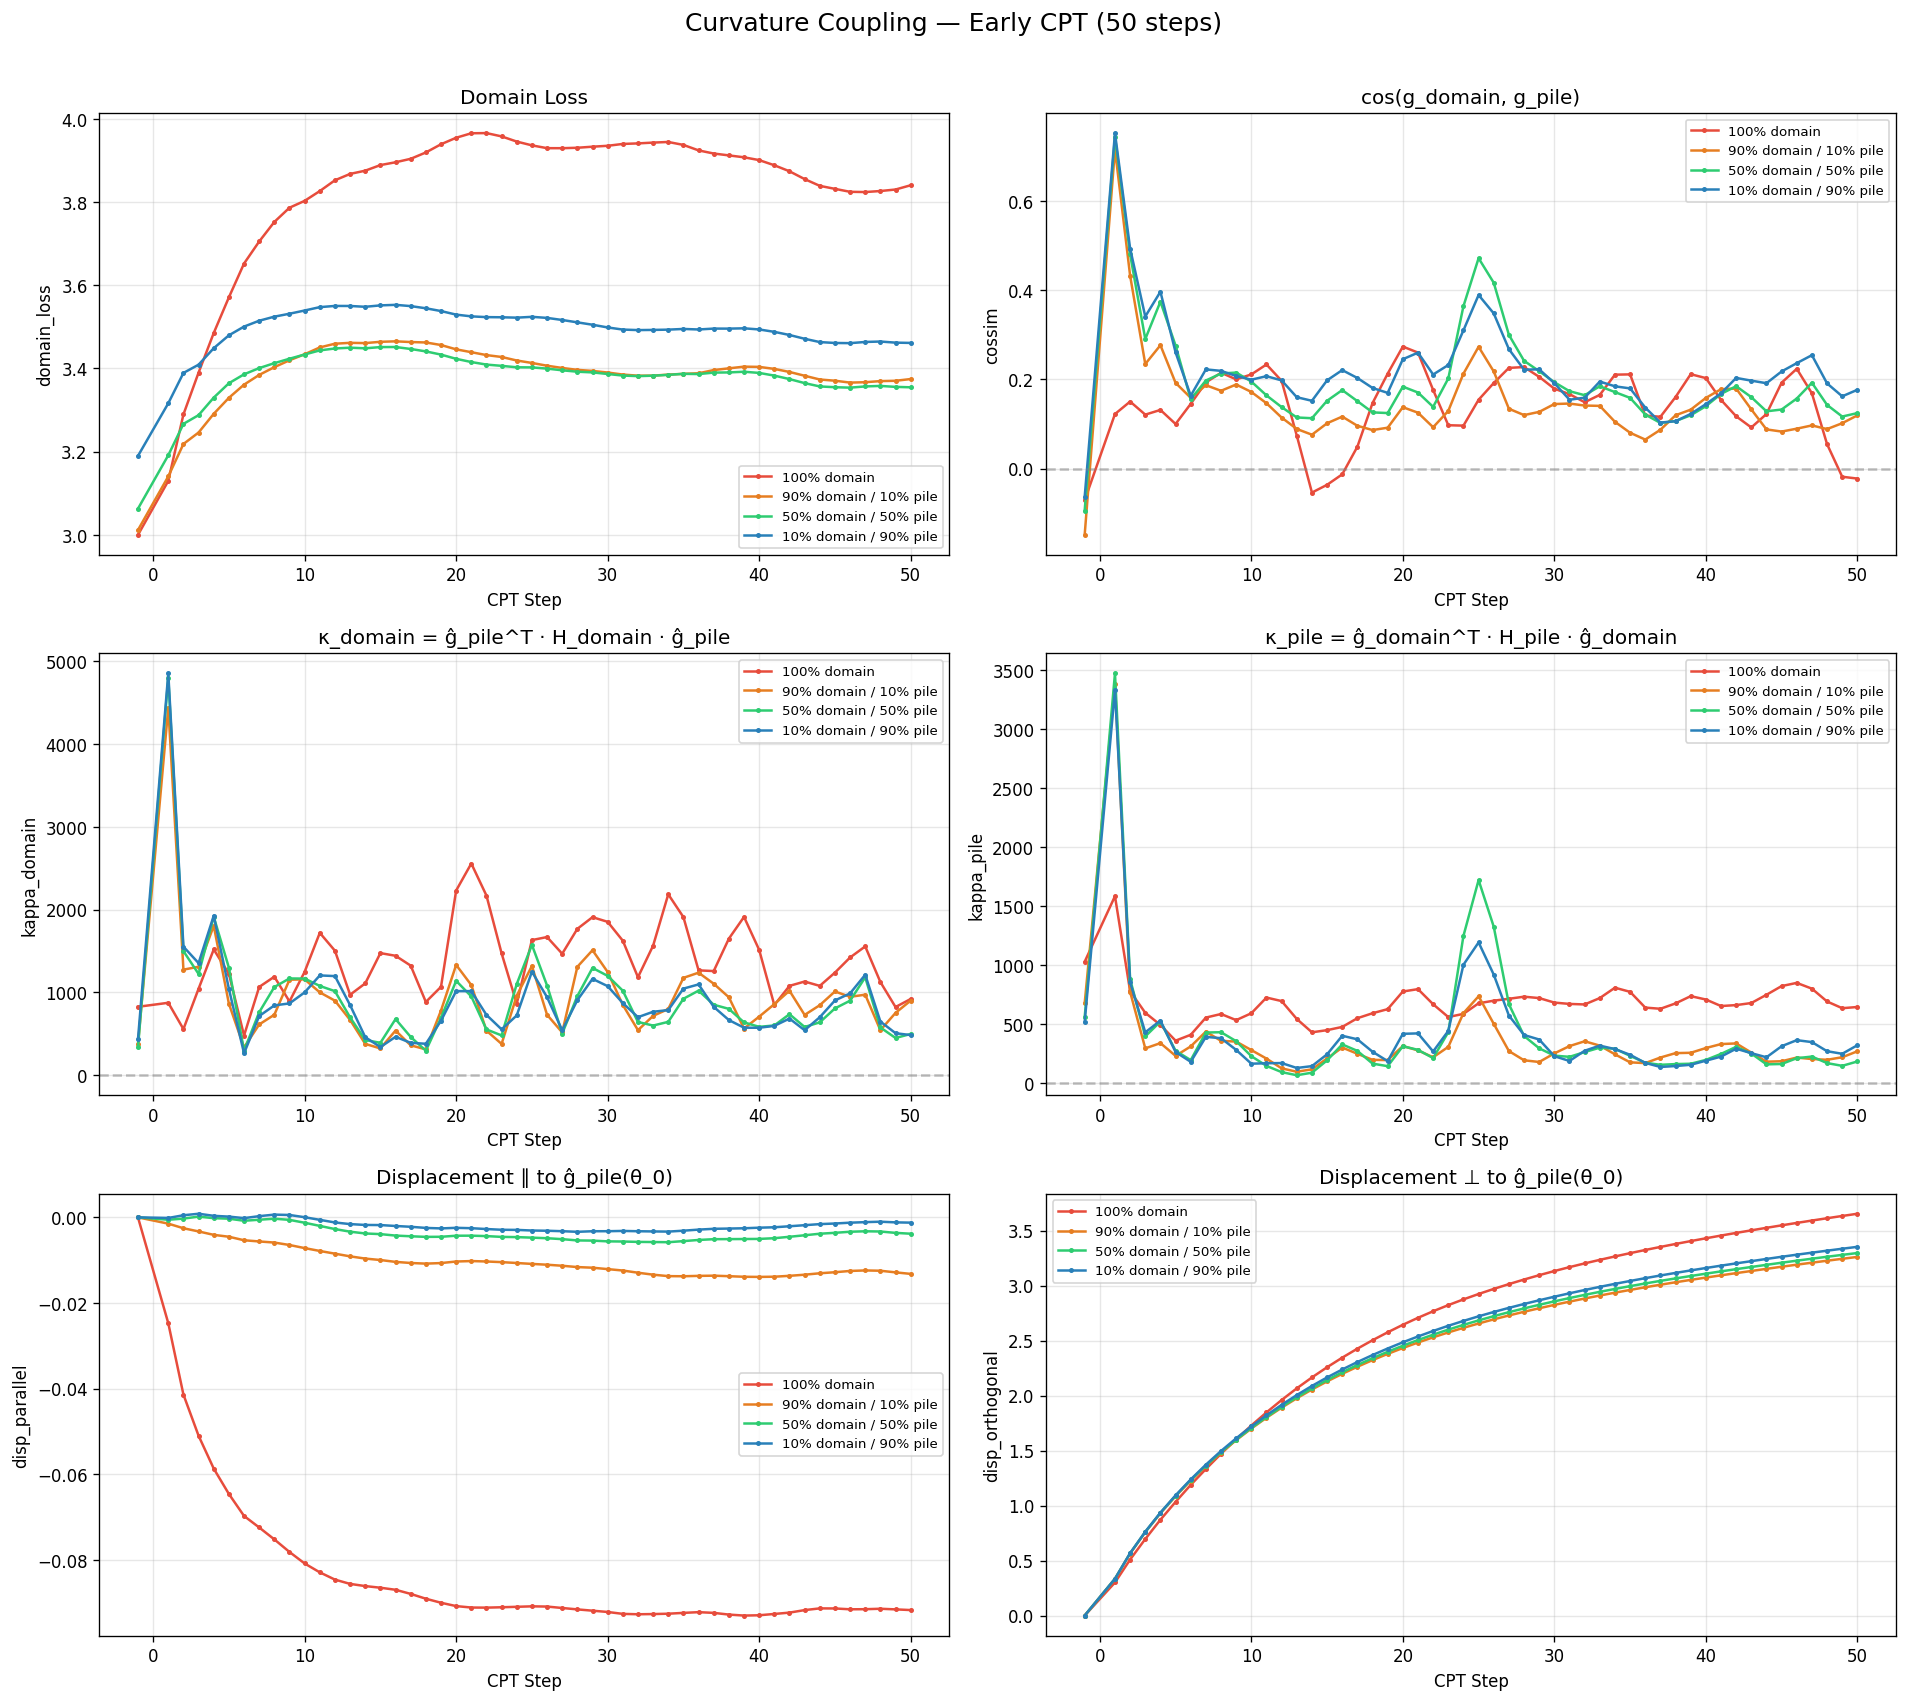

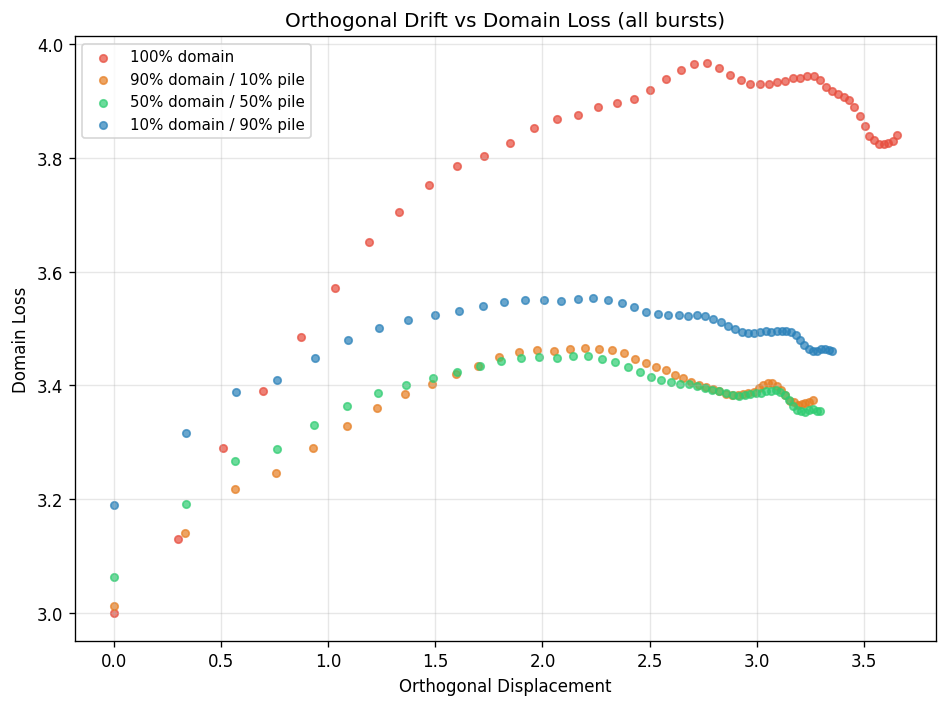

In [ ]:
# ── Plot κ tracking — all bursts overlaid ──
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
metrics_to_plot = [
    (axes[0, 0], "domain_loss", "Domain Loss"),
    (axes[0, 1], "cossim", "cos(g_domain, g_pile)"),
    (axes[1, 0], "kappa_domain", "κ_domain = ĝ_pile^T · H_domain · ĝ_pile"),
    (axes[1, 1], "kappa_pile", "κ_pile = ĝ_domain^T · H_pile · ĝ_domain"),
    (axes[2, 0], "disp_parallel", "Displacement ∥ to ĝ_pile(θ_0)"),
    (axes[2, 1], "disp_orthogonal", "Displacement ⊥ to ĝ_pile(θ_0)"),
]
for ax, key, title in metrics_to_plot:
    for bl in BURSTS:
        tdf = all_tracking[bl]
        color = plot_module.BURST_COLORS.get(bl, "gray")
        label = plot_module.BURST_LABELS.get(bl, f"{bl:.0%}")
        ax.plot(tdf["step"], tdf[key], "o-", color=color, ms=2, lw=1.5, label=label)
    if key in ("cossim", "kappa_domain", "kappa_pile"):
        ax.axhline(0, color="gray", ls="--", alpha=0.5)
    ax.set_xlabel("CPT Step"); ax.set_ylabel(key); ax.set_title(title)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle(f"Curvature Coupling — Early CPT ({NUM_TRACK_STEPS} steps)", fontsize=15, y=1.01)
fig.tight_layout(); display(fig); plt.close(fig)

# Bonus: orthogonal drift vs domain loss scatter (color = burst)
fig, ax = plt.subplots(figsize=(8, 6))
for bl in BURSTS:
    tdf = all_tracking[bl]
    color = plot_module.BURST_COLORS.get(bl, "gray")
    label = plot_module.BURST_LABELS.get(bl, f"{bl:.0%}")
    ax.scatter(tdf["disp_orthogonal"], tdf["domain_loss"], color=color, s=20, label=label, alpha=0.7)
ax.set_xlabel("Orthogonal Displacement"); ax.set_ylabel("Domain Loss")
ax.set_title("Orthogonal Drift vs Domain Loss (all bursts)")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
fig.tight_layout(); display(fig); plt.close(fig)


### Straight-line Comparison
Compare domain loss at θ_N (actual CPT endpoint after N steps) vs θ_linear = θ_0 + ||θ_N - θ_0|| * ĝ_pile(θ_0).
Same displacement magnitude, but perfectly straight along initial pile gradient. Excess = curvature bent the path.

In [ ]:
# ── Straight-line comparison — all burst levels ──
SL_STEPS = NUM_TRACK_STEPS

sl_results = []
for bl in BURSTS:
    bd = burst_data[bl]
    sl_model = AutoModelForCausalLM.from_pretrained(bd["ckpt_dir"], torch_dtype=torch.float32).to(device)
    sl_model.train()
    sl_opt = torch.optim.AdamW(sl_model.parameters(), lr=cfg.cpt_lr, weight_decay=cfg.cpt_weight_decay)
    sl_loader = make_pile_loader(datasets["pile_train"], cfg.cpt_batch_size, seed=cfg.seed)
    sl_iter = iter(sl_loader)

    for _ in tqdm(range(SL_STEPS), desc=f"SL burst={bl:.0%}"):
        try:
            batch = next(sl_iter)
        except StopIteration:
            sl_iter = iter(sl_loader)
            batch = next(sl_iter)
        input_ids = batch.to(device)
        out = sl_model(input_ids=input_ids, labels=input_ids)
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(sl_model.parameters(), cfg.max_grad_norm)
        sl_opt.step(); sl_opt.zero_grad()

    theta_N = get_flat_params(sl_model)
    disp_norm = (theta_N - bd["theta_0"]).norm().item()

    sl_model.eval()
    d_actual = eval_loss(sl_model, datasets["domain_valid"])
    p_actual = eval_loss(sl_model, datasets["pile_valid"])

    # θ_linear
    set_flat_params(sl_model, bd["theta_0"] + disp_norm * bd["g_pile_hat"])
    d_linear = eval_loss(sl_model, datasets["domain_valid"])
    p_linear = eval_loss(sl_model, datasets["pile_valid"])

    # θ_0
    set_flat_params(sl_model, bd["theta_0"])
    d_0 = eval_loss(sl_model, datasets["domain_valid"])
    p_0 = eval_loss(sl_model, datasets["pile_valid"])

    del sl_model; torch.cuda.empty_cache()

    sl_results.append({
        "burst": bl, "disp_norm": disp_norm,
        "d_loss_0": d_0, "d_loss_actual": d_actual, "d_loss_linear": d_linear,
        "p_loss_0": p_0, "p_loss_actual": p_actual, "p_loss_linear": p_linear,
        "d_excess": d_actual - d_linear,
    })

sl_df = pd.DataFrame(sl_results)
display(sl_df[["burst", "d_loss_0", "d_loss_actual", "d_loss_linear", "d_excess"]])


=== Straight-line Comparison ===
After N CPT steps, compare domain loss at:
  θ_0:      the post-FT checkpoint (starting point)
  θ_N:      where the optimizer actually ended up
  θ_linear: θ_0 + ||θ_N - θ_0|| · ĝ_pile(θ_0) — same displacement magnitude, perfectly straight

If d_loss(θ_N) > d_loss(θ_linear):
  → the optimizer's curved path bent into domain-sensitive regions (trajectory curvature hurts)
If d_loss(θ_N) ≤ d_loss(θ_linear):
  → the straight path along the initial gradient is worse or equal (damage is from the direction itself)
d_excess = d_loss(θ_N) - d_loss(θ_linear) quantifies how much the curved path matters.



Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

SL burst=100%:   0%|          | 0/50 [00:00<?, ?it/s]

SL burst=100%: 100%|██████████| 50/50 [00:04<00:00, 11.52it/s]


burst=100%  d_0=2.9996  d_actual=3.8387  d_linear=573.4472  excess=-569.6085


...

burst=50%  d_0=3.0627  d_actual=3.3542  d_linear=295.0102  excess=-291.6560


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

SL burst=10%: 100%|██████████| 50/50 [00:04<00:00, 11.50it/s]


burst=10%  d_0=3.1896  d_actual=3.4604  d_linear=334.7560  excess=-331.2957


,burst,d_loss_0,d_loss_actual,d_loss_linear,d_excess
0,1.0,2.999568,3.838711,573.447198,-569.608488
1,0.9,3.011359,3.363149,213.772209,-210.409060
2,0.5,3.062740,3.354155,295.010153,-291.655999
3,0.1,3.189616,3.460355,334.756009,-331.295654


### Cross-burst κ Comparison
Compare κ at the post-FT checkpoint across different burst levels.
κ is a property of the landscape geometry — does the training mixture change it?

In [ ]:
# ── Cross-burst κ comparison at post-FT checkpoints ──
models_dir = os.path.join(RESULTS_DIR, "models")
burst_dirs = sorted(glob.glob(os.path.join(models_dir, "burst_*/post_finetune")))

cross_burst = []
for bd in burst_dirs:
    bl_str = os.path.basename(os.path.dirname(bd)).replace("burst_", "").replace("_", ".")
    bl = float(bl_str)

    m = AutoModelForCausalLM.from_pretrained(os.path.abspath(bd), torch_dtype=torch.float32).to(device)
    m.eval()

    g_d = get_grad_vector(m, datasets["domain_valid"])
    g_p = get_grad_vector(m, datasets["pile_valid"])
    cs = F.cosine_similarity(g_d.unsqueeze(0), g_p.unsqueeze(0)).item()

    g_p_hat = g_p / g_p.norm()
    g_d_hat = g_d / g_d.norm()
    k_d = compute_kappa(m, g_p_hat, datasets["domain_valid"])
    k_p = compute_kappa(m, g_d_hat, datasets["pile_valid"])

    d_loss = eval_loss(m, datasets["domain_valid"])
    p_loss = eval_loss(m, datasets["pile_valid"])

    del m; torch.cuda.empty_cache()

    cross_burst.append({
        "burst_level": bl, "cossim": cs,
        "kappa_domain": k_d, "kappa_pile": k_p,
        "domain_loss": d_loss, "pile_loss": p_loss,
        "domain_grad_norm": g_d.norm().item(), "pile_grad_norm": g_p.norm().item(),
    })

cbdf = pd.DataFrame(cross_burst).sort_values("burst_level", ascending=False)
display(cbdf)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  burst=10%  cossim=-0.0640  κ_d=434.1445  κ_p=515.5204  d_loss=3.1896  p_loss=2.7384


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  burst=25%  cossim=-0.0801  κ_d=381.7711  κ_p=459.7794  d_loss=3.1167  p_loss=2.7453


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  burst=98%  cossim=-0.1428  κ_d=459.2507  κ_p=706.1889  d_loss=3.0025  p_loss=2.9647


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  burst=100%  cossim=-0.0713  κ_d=825.4570  κ_p=1030.9589  d_loss=2.9996  p_loss=5.0612


,burst_level,cossim,kappa_domain,kappa_pile,domain_loss,pile_loss,domain_grad_norm,pile_grad_norm
7,1.00,-0.071312,825.456970,1030.958862,2.999568,5.061223,3.364385,41.713146
6,0.98,-0.142794,459.250671,706.188904,3.002490,2.964708,3.356682,3.816001
5,0.95,-0.146032,378.360840,695.436890,3.007399,2.886461,3.382336,3.505160
4,0.90,-0.149046,371.396240,669.900757,3.011359,2.841334,3.352416,3.127439
3,0.75,-0.111481,342.325623,640.322632,3.028840,2.794113,3.342885,3.009012
2,0.50,-0.094514,333.324646,550.526367,3.062740,2.761707,3.344189,2.951294
1,0.25,-0.080093,381.771118,459.779419,3.116692,2.745303,3.411219,2.932096
0,0.10,-0.063955,434.144470,515.520386,3.189616,2.738436,3.636160,2.921966


=== Cross-Burst Comparison at Post-FT Checkpoints ===
Bar charts comparing all burst levels at their post-finetune checkpoint:
  Left:   cos(g_domain, g_pile) — does higher burst (more domain) create more gradient conflict?
  Middle: κ_domain and κ_pile — does the landscape geometry change with training mixture?
          κ is a property of the loss surface, but the training mixture shapes where you end up on it.
  Right:  Gradient norms — magnitude of domain vs pile gradients at each checkpoint.



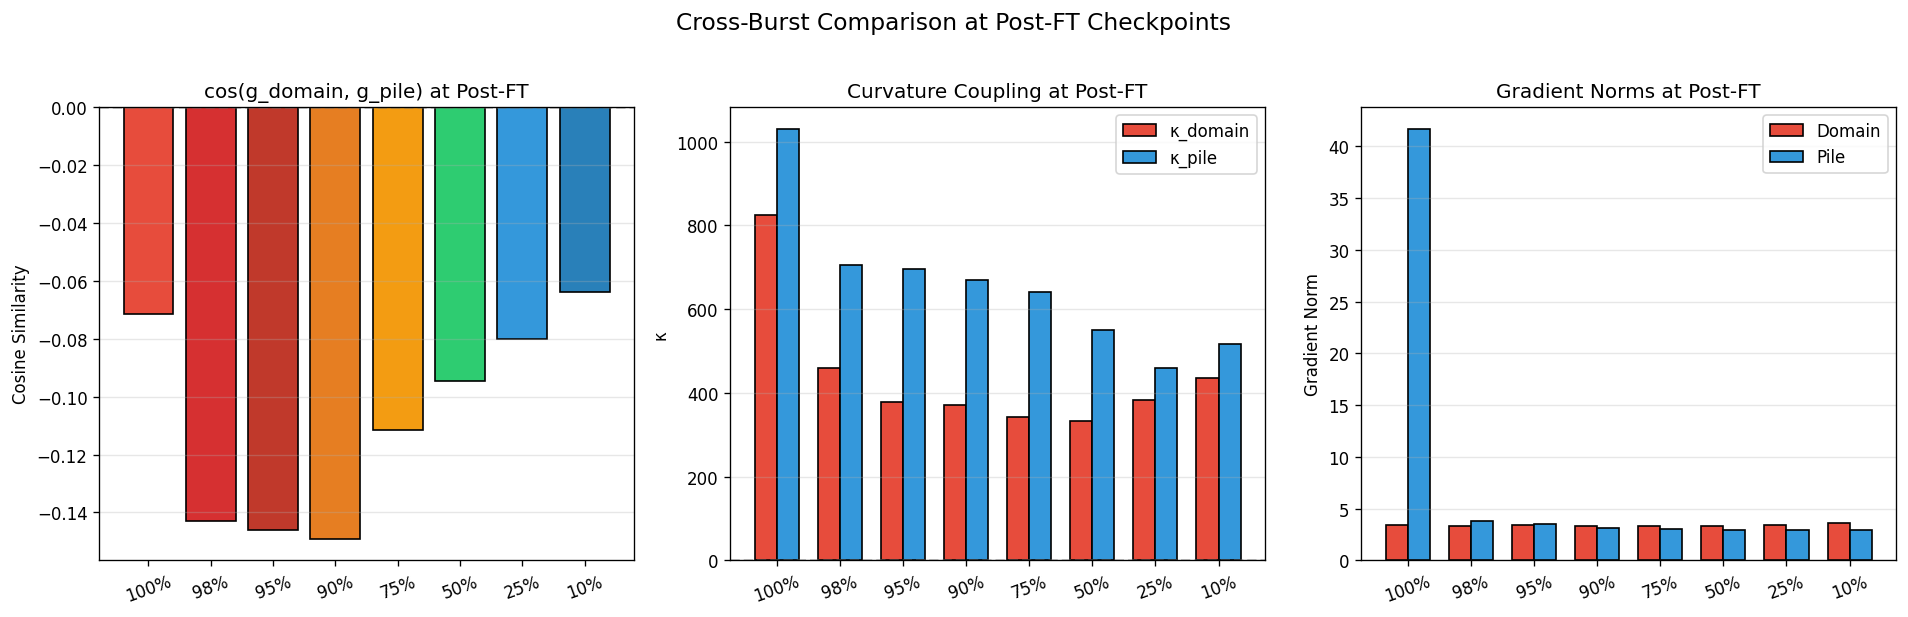

In [ ]:
# ── Plot cross-burst comparison ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bls = cbdf["burst_level"]

ax = axes[0]
ax.bar(range(len(bls)), cbdf["cossim"], color=[plot_module.BURST_COLORS.get(b, "gray") for b in bls], edgecolor="black")
ax.set_xticks(range(len(bls))); ax.set_xticklabels([f"{b:.0%}" for b in bls], rotation=20)
ax.set_ylabel("Cosine Similarity"); ax.set_title("cos(g_domain, g_pile) at Post-FT")
ax.axhline(0, color="gray", ls="--", alpha=0.5); ax.grid(axis="y", alpha=0.3)

ax = axes[1]
x = np.arange(len(bls)); w = 0.35
ax.bar(x - w/2, cbdf["kappa_domain"], w, color="#e74c3c", edgecolor="black", label="κ_domain")
ax.bar(x + w/2, cbdf["kappa_pile"], w, color="#3498db", edgecolor="black", label="κ_pile")
ax.set_xticks(x); ax.set_xticklabels([f"{b:.0%}" for b in bls], rotation=20)
ax.set_ylabel("κ"); ax.set_title("Curvature Coupling at Post-FT")
ax.axhline(0, color="gray", ls="--", alpha=0.5); ax.legend(); ax.grid(axis="y", alpha=0.3)

ax = axes[2]
ax.bar(x - w/2, cbdf["domain_grad_norm"], w, color="#e74c3c", edgecolor="black", label="Domain")
ax.bar(x + w/2, cbdf["pile_grad_norm"], w, color="#3498db", edgecolor="black", label="Pile")
ax.set_xticks(x); ax.set_xticklabels([f"{b:.0%}" for b in bls], rotation=20)
ax.set_ylabel("Gradient Norm"); ax.set_title("Gradient Norms at Post-FT")
ax.legend(); ax.grid(axis="y", alpha=0.3)

fig.suptitle("Cross-Burst Comparison at Post-FT Checkpoints", fontsize=14, y=1.02)
fig.tight_layout(); display(fig); plt.close(fig)